# Experiment Results Exploratory Data Analysis

This notebook analyses the difficulty data results from the Godot prototype.

The purpose of this analysis is to examine how different simulated player profiles perform under the different difficulty settings, and will be compared with each other.

## 1. Static Difficulty Setup

All player profiles have been tested on a static difficulty of 5, on a scale of 1-10.

### Creating the Combined Static Baseline Dataset

The raw CSV files generated by Godot are loaded, combined, cleaned, and saved as one processed dataset.  
The rest of the notebook uses this combined CSV file rather than repeatedly loading the individual raw files.

In [91]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RAW_DATA_DIR = Path("../godot_project/game_project/data/raw")
PROCESSED_DATA_DIR = Path("../data/processed")
FIGURE_DIR = Path("../results/figures")
TABLE_DIR = Path("../results/tables")

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

COMBINED_DATA_PATH = PROCESSED_DATA_DIR / "static_baseline_combined.csv"

PROFILE_ORDER = [
    "beginner",
    "intermediate",
    "skilled",
    "inconsistent",
    "improving",
]

files = {
    "beginner": "static_difficulty_5_beginner_logged.csv",
    "intermediate": "static_difficulty_5_intermediate_logged.csv",
    "skilled": "static_difficulty_5_skilled_logged.csv",
    "inconsistent": "static_difficulty_5_inconsistent_logged.csv",
    "improving": "static_difficulty_5_improving_logged.csv",
}

# Backfill static CSVs with difficulty-tracking columns.
for file_name in files.values():
    file_path = RAW_DATA_DIR / file_name

    if not file_path.exists():
        print(f"Skipping missing file: {file_path}")
        continue

    df = pd.read_csv(file_path)

    if "final_difficulty" not in df.columns:
        raise ValueError(f"{file_name} does not contain final_difficulty.")

    df["final_difficulty"] = pd.to_numeric(df["final_difficulty"], errors="coerce")
    df["survival_time"] = pd.to_numeric(df["survival_time"], errors="coerce")

    # Static difficulty does not change during the run.
    df["initial_difficulty"] = df["final_difficulty"]
    df["average_difficulty"] = df["final_difficulty"]
    df["min_difficulty"] = df["final_difficulty"]
    df["max_difficulty"] = df["final_difficulty"]
    df["difficulty_changes"] = 0

    # This cannot be recovered accurately from old summary-only CSVs.
    # It will be logged properly in rule-based and RL experiments.
    df["time_in_target_range"] = pd.NA

    # Useful proxy for static baseline analysis.
    df["within_target_survival_range"] = df["survival_time"].between(
        40,
        60,
        inclusive="both",
    )

    backup_path = file_path.with_suffix(".backup.csv")

    if not backup_path.exists():
        pd.read_csv(file_path).to_csv(backup_path, index=False)

    df.to_csv(file_path, index=False)

    print(f"Updated: {file_name}")

# Load the updated raw CSV files and combine them.
frames = []

for profile, file_name in files.items():
    file_path = RAW_DATA_DIR / file_name

    df = pd.read_csv(file_path)
    df["profile"] = profile

    frames.append(df)

combined = pd.concat(frames, ignore_index=True)

combined["player_died"] = (
    combined["player_died"]
    .astype(str)
    .str.lower()
    .isin(["true", "1", "yes"])
)

numeric_columns = [
    "run_number",
    "survival_time",
    "score",
    "health_remaining",
    "hits_taken",
    "deaths",
    "final_difficulty",
    "initial_difficulty",
    "average_difficulty",
    "min_difficulty",
    "max_difficulty",
    "difficulty_changes",
    "time_in_target_range",
    "profile_speed",
    "profile_reaction_time",
    "profile_dodge_chance",
    "profile_mistake_chance",
    "profile_detection_radius",
    "profile_dodge_duration",
    "profile_strafe_weight",
    "profile_retreat_weight",
]

for column in numeric_columns:
    if column in combined.columns:
        combined[column] = pd.to_numeric(combined[column], errors="coerce")

combined["profile"] = pd.Categorical(
    combined["profile"],
    categories=PROFILE_ORDER,
    ordered=True,
)

combined = combined.sort_values(["profile", "run_number"]).reset_index(drop=True)

combined.to_csv(COMBINED_DATA_PATH, index=False)

COMBINED_DATA_PATH

Updated: static_difficulty_5_beginner_logged.csv
Updated: static_difficulty_5_intermediate_logged.csv
Updated: static_difficulty_5_skilled_logged.csv
Updated: static_difficulty_5_inconsistent_logged.csv
Updated: static_difficulty_5_improving_logged.csv


PosixPath('../data/processed/static_baseline_combined.csv')

## 2. Loading the Static Baseline Data

The CSV files generated by the Godot experiment manager are loaded and combined into one dataframe.  
Each row represents one simulation run.

In [92]:
results = pd.read_csv(COMBINED_DATA_PATH)

results["profile"] = pd.Categorical(
    results["profile"],
    categories=PROFILE_ORDER,
    ordered=True,
)

results.head()

,profile_name,system_name,run_number,player_died,survival_time,score,health_remaining,hits_taken,deaths,final_difficulty,...,profile_strafe_weight,profile_retreat_weight,initial_difficulty,average_difficulty,min_difficulty,max_difficulty,difficulty_changes,time_in_target_range,within_target_survival_range,profile
0,beginner,static,1,False,60.00,600,6.5,11,0,5,...,0.6,0.2,5,5,5,5,0,NaN,True,beginner
1,beginner,static,2,True,59.50,595,0.0,12,1,5,...,0.6,0.2,5,5,5,5,0,NaN,True,beginner
2,beginner,static,3,True,59.00,590,0.0,12,1,5,...,0.6,0.2,5,5,5,5,0,NaN,True,beginner
3,beginner,static,4,True,43.17,431,0.0,12,1,5,...,0.6,0.2,5,5,5,5,0,NaN,True,beginner
4,beginner,static,5,False,60.00,600,40.5,7,0,5,...,0.6,0.2,5,5,5,5,0,NaN,True,beginner


In [93]:
results["player_died"] = results["player_died"].astype(str).str.lower().isin(["true", "1", "yes"])

numeric_columns = [
    "run_number",
    "survival_time",
    "score",
    "health_remaining",
    "hits_taken",
    "deaths",
    "final_difficulty",
    "profile_speed",
    "profile_reaction_time",
    "profile_dodge_chance",
    "profile_mistake_chance",
    "profile_detection_radius",
    "profile_dodge_duration",
    "profile_strafe_weight",
    "profile_retreat_weight",
]

for column in numeric_columns:
    if column in results.columns:
        results[column] = pd.to_numeric(results[column], errors="coerce")

results["profile"] = pd.Categorical(
    results["profile"],
    categories=PROFILE_ORDER,
    ordered=True,
)

results = results.sort_values(["profile", "run_number"]).reset_index(drop=True)

results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   profile_name                  150 non-null    object  
 1   system_name                   150 non-null    object  
 2   run_number                    150 non-null    int64   
 3   player_died                   150 non-null    bool    
 4   survival_time                 150 non-null    float64 
 5   score                         150 non-null    int64   
 6   health_remaining              150 non-null    float64 
 7   hits_taken                    150 non-null    int64   
 8   deaths                        150 non-null    int64   
 9   final_difficulty              150 non-null    int64   
 10  profile_speed                 150 non-null    float64 
 11  profile_reaction_time         150 non-null    float64 
 12  profile_dodge_chance          150 non-null    floa

## 3. Static Difficulty EDA

### Summary Statistics

This section summarises the static baseline results by profile.  
The key measures are deaths, survivals, death rate, average survival time, health remaining, and hits taken.

In [94]:
summary = (
    results
    .groupby("profile", observed=False)
    .agg(
        runs=("run_number", "count"),
        deaths=("player_died", "sum"),
        average_survival_time=("survival_time", "mean"),
        median_survival_time=("survival_time", "median"),
        min_survival_time=("survival_time", "min"),
        max_survival_time=("survival_time", "max"),
        average_health_remaining=("health_remaining", "mean"),
        average_hits_taken=("hits_taken", "mean"),
    )
    .reset_index()
)

summary["survivals"] = summary["runs"] - summary["deaths"]
summary["death_rate"] = (summary["deaths"] / summary["runs"]) * 100
summary["survival_rate"] = (summary["survivals"] / summary["runs"]) * 100

summary = summary[
    [
        "profile",
        "runs",
        "deaths",
        "survivals",
        "death_rate",
        "survival_rate",
        "average_survival_time",
        "median_survival_time",
        "min_survival_time",
        "max_survival_time",
        "average_health_remaining",
        "average_hits_taken",
    ]
]

summary.round(2)

,profile,runs,deaths,survivals,death_rate,survival_rate,average_survival_time,median_survival_time,min_survival_time,max_survival_time,average_health_remaining,average_hits_taken
0,beginner,30,22,8,73.33,26.67,49.45,52.25,29.25,60.0,5.13,11.33
1,intermediate,30,11,19,36.67,63.33,56.26,60.00,36.08,60.0,17.43,9.80
2,skilled,30,5,25,16.67,83.33,59.06,60.00,47.50,60.0,27.80,8.53
3,inconsistent,30,13,17,43.33,56.67,56.20,60.00,41.33,60.0,17.00,9.87
4,improving,30,17,13,56.67,43.33,52.22,59.21,19.00,60.0,11.88,10.50


Concise summary

In [95]:
for _, row in summary.iterrows():
    profile = row["profile"]
    deaths = int(row["deaths"])
    runs = int(row["runs"])
    death_rate = row["death_rate"]
    avg_survival = row["average_survival_time"]
    
    print(
        f"{profile}: {deaths}/{runs} deaths "
        f"({death_rate:.1f}% death rate), "
        f"average survival time = {avg_survival:.2f}s."
    )

beginner: 22/30 deaths (73.3% death rate), average survival time = 49.45s.
intermediate: 11/30 deaths (36.7% death rate), average survival time = 56.26s.
skilled: 5/30 deaths (16.7% death rate), average survival time = 59.06s.
inconsistent: 13/30 deaths (43.3% death rate), average survival time = 56.20s.
improving: 17/30 deaths (56.7% death rate), average survival time = 52.22s.


### Interpretation

The summary statistics show whether static difficulty level 5 is suitable for each simulated player profile.  
A medium difficulty should produce mixed outcomes, while a very high death rate suggests the difficulty is too hard and a very low death rate suggests it is too easy.

### Death Rate by Profile

This chart compares the percentage of failed runs for each simulated player profile.

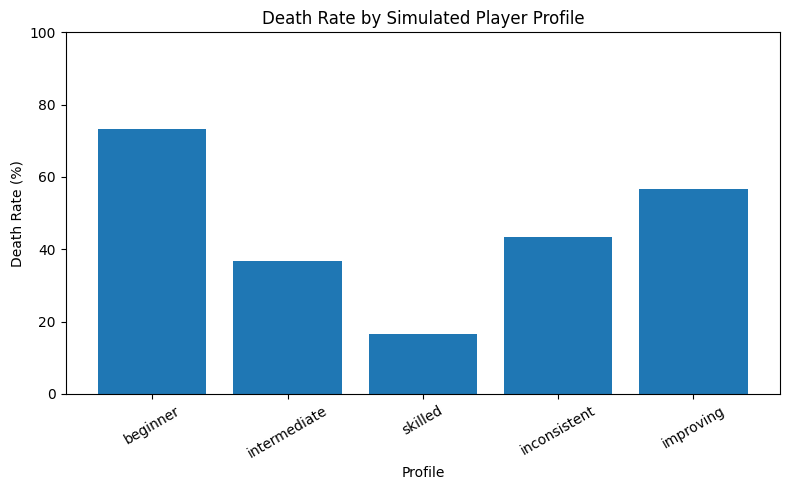

In [96]:
plt.figure(figsize=(8, 5))
plt.bar(summary["profile"].astype(str), summary["death_rate"])

plt.title("Death Rate by Simulated Player Profile")
plt.xlabel("Profile")
plt.ylabel("Death Rate (%)")
plt.ylim(0, 100)
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "static_death_rate_by_profile.png", dpi=300)
plt.show()

### Interpretation

The death rate chart shows how uneven static difficulty is across profiles.  
A high death rate for the beginner profile suggests that static difficulty level 5 is too hard for weaker behaviour.  
A low death rate for the skilled profile suggests that the same difficulty is too easy for stronger behaviour.

### Static Baseline Outcomes by Profile

This chart compares the number of deaths and survivals for each simulated player profile under static difficulty level 5.

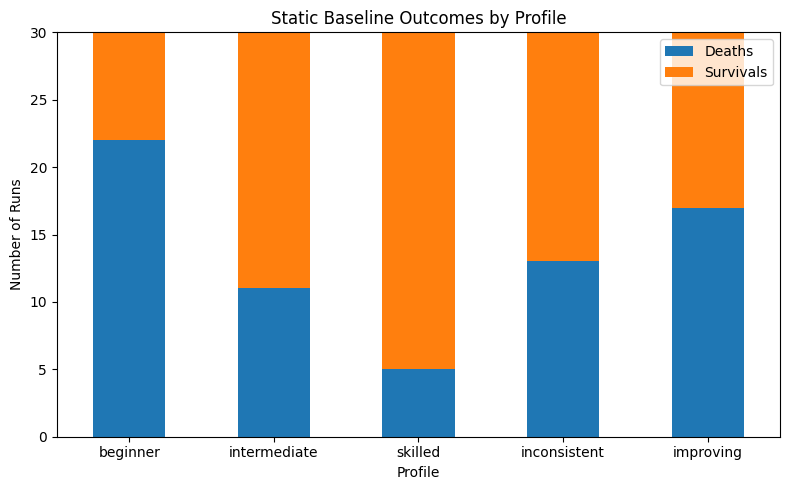

,profile,deaths,runs,survivals
0,beginner,22,30,8
1,intermediate,11,30,19
2,skilled,5,30,25
3,inconsistent,13,30,17
4,improving,17,30,13


In [97]:
static_results = results.copy()

static_outcomes = (
    static_results
    .groupby("profile", observed=False)
    .agg(
        deaths=("player_died", "sum"),
        runs=("run_number", "count"),
    )
    .reset_index()
)

static_outcomes["survivals"] = (
    static_outcomes["runs"] - static_outcomes["deaths"]
)

ax = static_outcomes.plot(
    x="profile",
    y=["deaths", "survivals"],
    kind="bar",
    stacked=True,
    figsize=(8, 5),
)

ax.set_title("Static Baseline Outcomes by Profile")
ax.set_xlabel("Profile")
ax.set_ylabel("Number of Runs")
ax.set_ylim(0, 30)
ax.legend(["Deaths", "Survivals"])
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "static_baseline_outcomes_by_profile.png", dpi=300)
plt.show()

static_outcomes

### Interpretation

This graph shows deaths and survivals for each profile under static difficulty level 5. Since the difficulty did not change, the differences are caused by the simulated player profiles.

The beginner profile died most often, while the skilled profile survived most often. This shows that one fixed difficulty level was too hard for weaker behaviour and too easy for stronger behaviour.

Overall, the static baseline shows why adaptive difficulty is needed.

### Average Survival Time by Profile

This chart compares how long each profile survived on average during the 60-second episode.

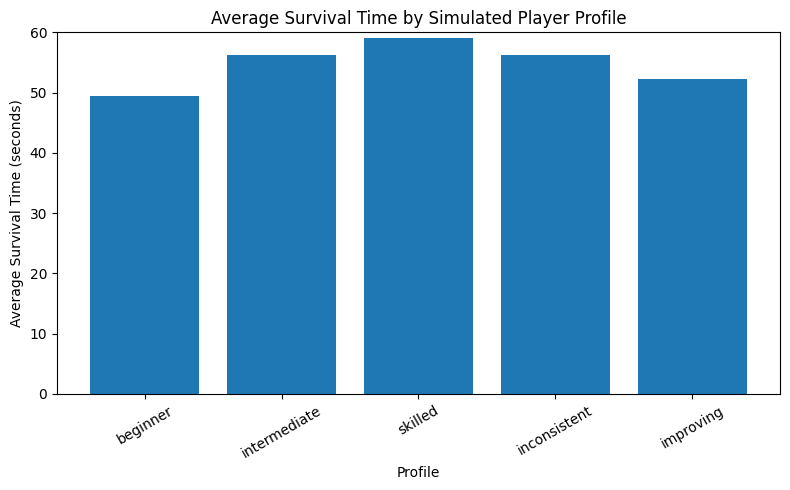

In [98]:
plt.figure(figsize=(8, 5))
plt.bar(summary["profile"].astype(str), summary["average_survival_time"])

plt.title("Average Survival Time by Simulated Player Profile")
plt.xlabel("Profile")
plt.ylabel("Average Survival Time (seconds)")
plt.ylim(0, 60)
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "static_average_survival_by_profile.png", dpi=300)
plt.show()

### Interpretation

Average survival time provides another view of difficulty balance.  
Profiles that survive close to 60 seconds are experiencing the static difficulty as easier, while profiles with lower survival times are experiencing greater challenge.

### Survival Time Distribution

Averages can hide variation between runs.  
The boxplot below shows the spread of survival times for each profile.

/var/folders/wr/yfqr6y3s6kzbnssvn_smcchh0000gn/T/ipykernel_4362/3928992622.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=PROFILE_ORDER)


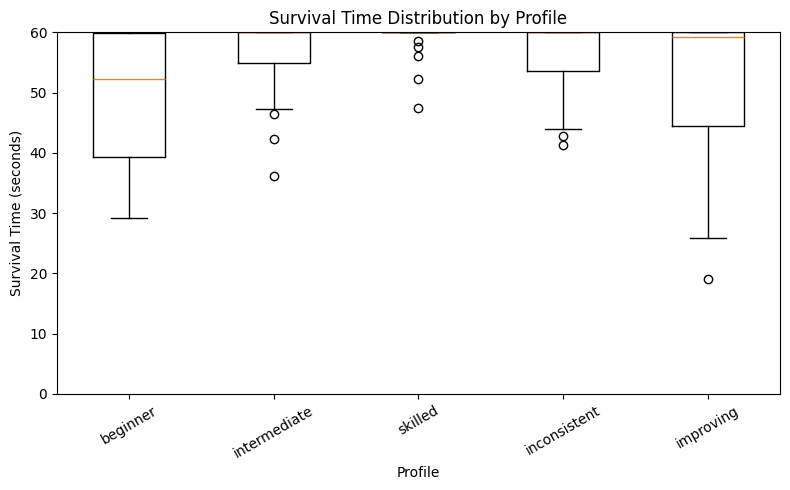

In [99]:
boxplot_data = [
    results.loc[results["profile"] == profile, "survival_time"]
    for profile in PROFILE_ORDER
]

plt.figure(figsize=(8, 5))
plt.boxplot(boxplot_data, labels=PROFILE_ORDER)

plt.title("Survival Time Distribution by Profile")
plt.xlabel("Profile")
plt.ylabel("Survival Time (seconds)")
plt.ylim(0, 60)
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "static_survival_time_distribution_by_profile.png", dpi=300)
plt.show()

### Interpretation

The boxplot shows the distribution of survival times for each simulated player profile. Several profiles have values clustered at 60 seconds because each episode has a maximum duration of 60 seconds. This means that survival time is capped, which causes some boxes to appear compressed near the top of the chart.

The beginner profile shows lower and more variable survival times, while the skilled profile is concentrated near the maximum survival time. The improving profile shows a wide spread because it begins with weaker behaviour and becomes stronger across later runs. This supports the intended design of the simulated player profiles.

### Health Remaining by Profile

Health remaining helps distinguish between comfortable survival and narrow survival.  
A profile may survive the full episode, but low remaining health suggests it was still under pressure.

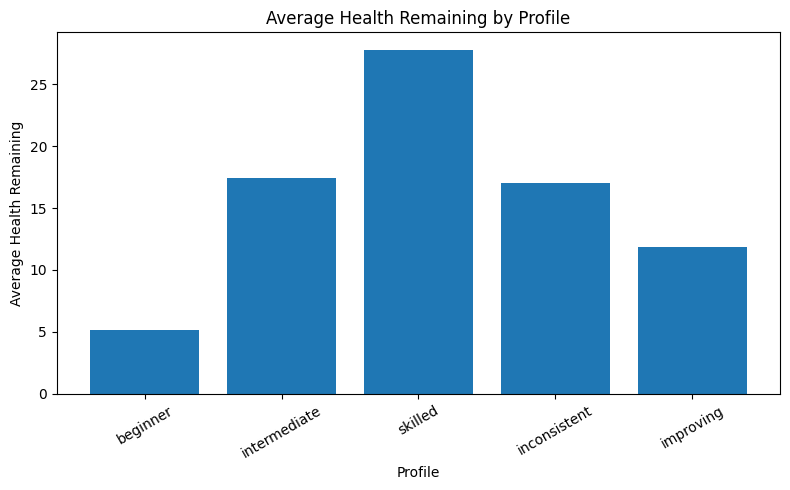

In [100]:
plt.figure(figsize=(8, 5))
plt.bar(summary["profile"].astype(str), summary["average_health_remaining"])

plt.title("Average Health Remaining by Profile")
plt.xlabel("Profile")
plt.ylabel("Average Health Remaining")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "static_average_health_remaining_by_profile.png", dpi=300)
plt.show()

### Interpretation

Average health remaining provides another indication of how much pressure each profile experienced. The beginner profile had the lowest average health remaining, showing that static difficulty level 5 was too difficult for weaker simulated player behaviour. The skilled profile had the highest average health remaining, suggesting that the same difficulty level was too easy for stronger behaviour.

The intermediate profile sat between beginner and skilled, supporting its role as the calibrated medium baseline. The improving profile had lower average health overall because its early runs used weaker behaviour settings, while the inconsistent profile remained close to intermediate overall but varied between runs.

### Hits Taken by Profile

Hits taken measures how often each profile was damaged during a run.  
This helps show whether profiles survived comfortably or survived after repeated damage.

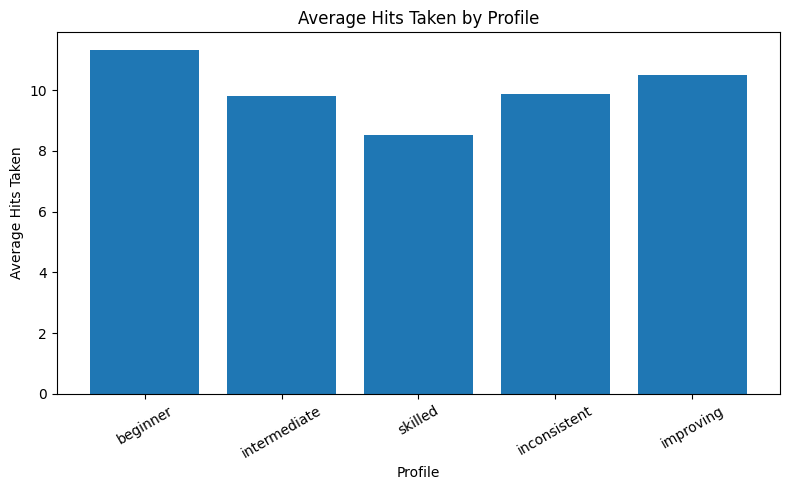

In [101]:
plt.figure(figsize=(8, 5))
plt.bar(summary["profile"].astype(str), summary["average_hits_taken"])

plt.title("Average Hits Taken by Profile")
plt.xlabel("Profile")
plt.ylabel("Average Hits Taken")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "static_average_hits_taken_by_profile.png", dpi=300)
plt.show()

### Interpretation

Average hits taken shows how much pressure each simulated player profile experienced under static difficulty level 5. The beginner profile took the most hits on average, which supports the finding that static difficulty level 5 was too difficult for weaker simulated behaviour. The skilled profile took the fewest hits, suggesting that the same difficulty level was too easy for stronger behaviour.

The intermediate profile sat between beginner and skilled, supporting its role as the calibrated medium baseline. The improving profile had a relatively high average number of hits because the early runs used weaker behaviour values before the profile improved across later runs.

### Improving Profile Trend

The improving profile is designed to become stronger over repeated runs.  
This plot shows whether survival time increases as the run number increases.

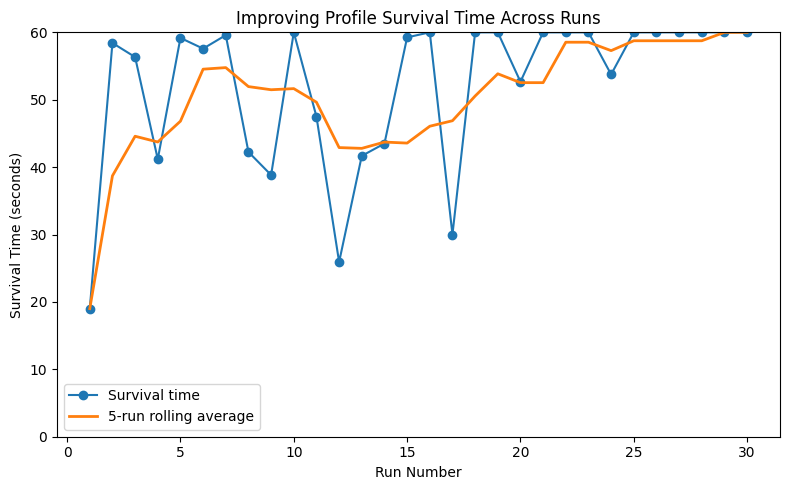

In [102]:
improving = results[results["profile"] == "improving"].copy()

improving["survival_time_rolling"] = (
    improving["survival_time"]
    .rolling(window=5, min_periods=1)
    .mean()
)

plt.figure(figsize=(8, 5))

plt.plot(
    improving["run_number"],
    improving["survival_time"],
    marker="o",
    label="Survival time"
)

plt.plot(
    improving["run_number"],
    improving["survival_time_rolling"],
    linewidth=2,
    label="5-run rolling average"
)

plt.title("Improving Profile Survival Time Across Runs")
plt.xlabel("Run Number")
plt.ylabel("Survival Time (seconds)")
plt.ylim(0, 60)
plt.legend()
plt.tight_layout()

plt.savefig(FIGURE_DIR / "improving_profile_survival_time_trend.png", dpi=300)
plt.show()

In [103]:
first_half = improving[improving["run_number"] <= 15]
second_half = improving[improving["run_number"] > 15]

first_half_deaths = first_half["player_died"].sum()
second_half_deaths = second_half["player_died"].sum()

print(f"Improving profile first 15 runs: {first_half_deaths}/15 deaths.")
print(f"Improving profile final 15 runs: {second_half_deaths}/15 deaths.")

Improving profile first 15 runs: 14/15 deaths.
Improving profile final 15 runs: 3/15 deaths.


### Interpretation

The improving profile shows a general upward trend in survival time across repeated runs. Individual runs still vary because the simulation includes random movement and projectile interactions, but the 5-run rolling average shows that performance becomes more stable over time.

Early runs include several lower survival times, while later runs more consistently reach the full 60-second episode duration. This supports the intended design of the improving profile, where behaviour parameters gradually shift from beginner-level values toward skilled-level values.

### Improving Profile Parameter Progression

This section checks whether the improving profile's internal behaviour values change across runs.

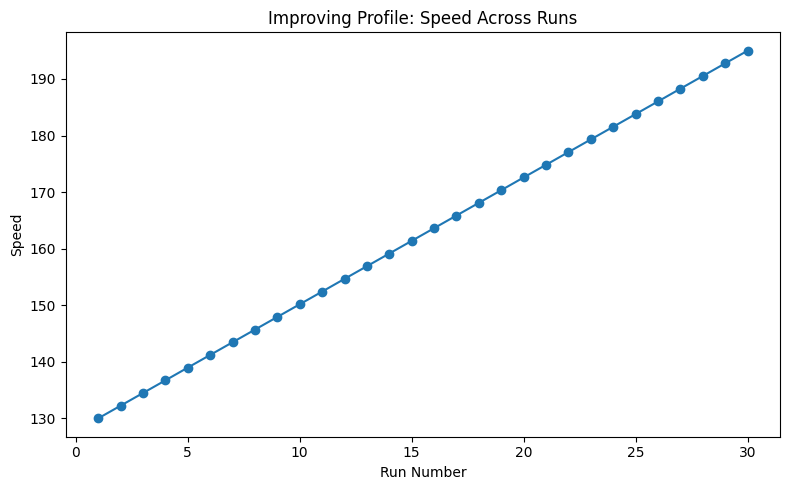

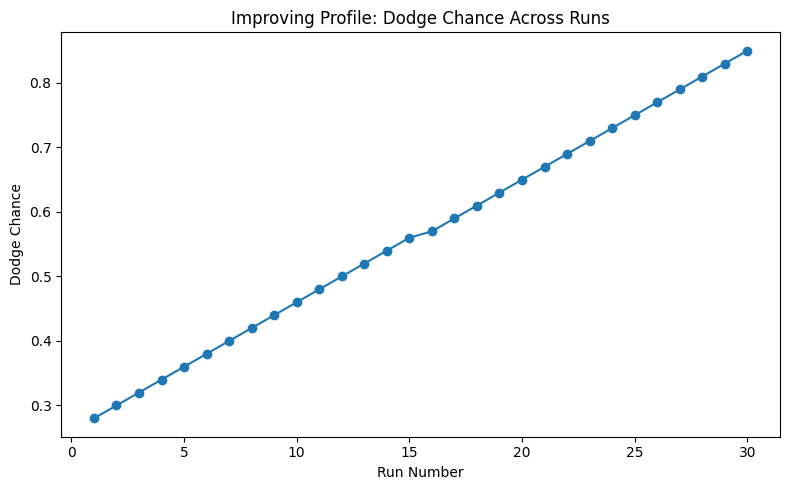

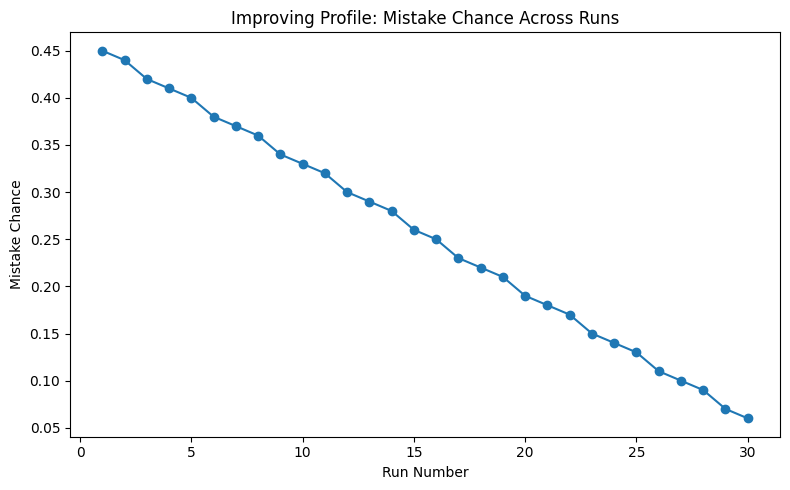

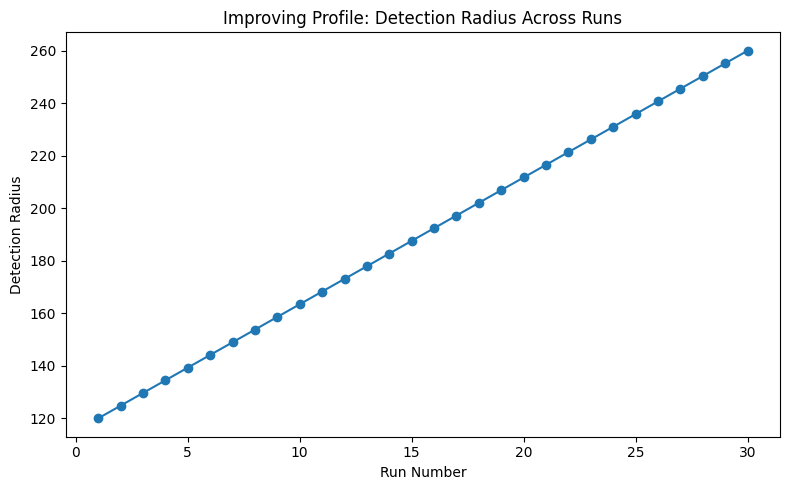

In [104]:
columns_to_plot = [
    "profile_speed",
    "profile_dodge_chance",
    "profile_mistake_chance",
    "profile_detection_radius",
]

for column in columns_to_plot:
    if column in improving.columns:
        plt.figure(figsize=(8, 5))
        plt.plot(improving["run_number"], improving[column], marker="o")
        
        readable_name = column.replace("profile_", "").replace("_", " ").title()
        plt.title(f"Improving Profile: {readable_name} Across Runs")
        plt.xlabel("Run Number")
        plt.ylabel(readable_name)
        plt.tight_layout()
        
        file_name = f"improving_profile_{column}_trend.png"
        plt.savefig(FIGURE_DIR / file_name, dpi=300)
        plt.show()

### Interpretation

These plots confirm that the improving profile changes its internal behaviour values across repeated runs. Movement speed, dodge chance, and detection radius increase steadily, while mistake chance decreases. This means the improving profile is not a fixed player profile. Instead, it gradually shifts from beginner-level behaviour toward skilled-level behaviour.

This supports the intended design of the improving profile. The later improvement in survival time can therefore be linked to the profile's changing behaviour parameters rather than being treated as random variation alone.

### Inconsistent Profile Parameter Variation

The inconsistent profile randomises its internal behaviour values between runs.  
This section checks whether those values actually vary across the experiment.

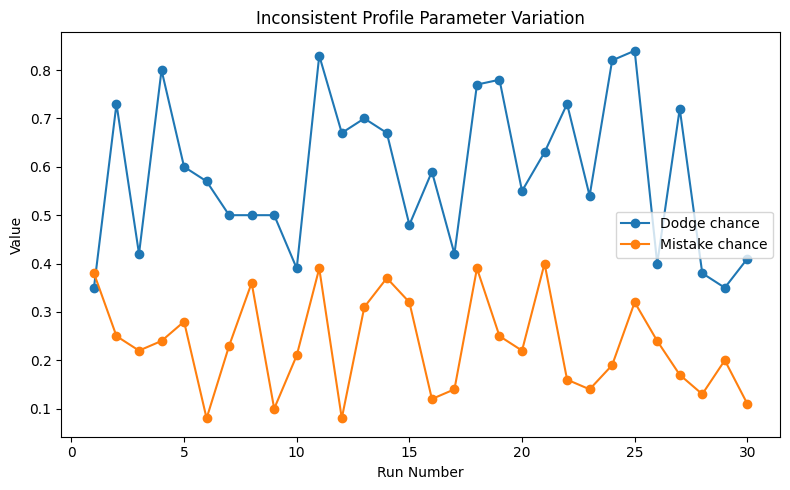

In [105]:
inconsistent = results[results["profile"] == "inconsistent"]

plt.figure(figsize=(8, 5))

plt.plot(
    inconsistent["run_number"],
    inconsistent["profile_dodge_chance"],
    marker="o",
    label="Dodge chance",
)

plt.plot(
    inconsistent["run_number"],
    inconsistent["profile_mistake_chance"],
    marker="o",
    label="Mistake chance",
)

plt.title("Inconsistent Profile Parameter Variation")
plt.xlabel("Run Number")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()

plt.savefig(FIGURE_DIR / "inconsistent_profile_parameter_variation.png", dpi=300)
plt.show()

### Interpretation

The inconsistent profile shows clear variation in its behaviour parameters across repeated runs. Dodge chance and mistake chance change from run to run rather than following a fixed trend. This confirms that the inconsistent profile represents unstable simulated player behaviour rather than a consistently weak, intermediate, or skilled player.

This variation is useful for the evaluation because an adaptive difficulty system should be able to respond to changing player performance, not only fixed skill levels.

### Static Baseline Interpretation

The static baseline results show that one fixed difficulty level does not suit every simulated player profile equally.

Difficulty level 5 is calibrated for the intermediate profile, but the same setting is too hard for the beginner profile and too easy for the skilled profile.  
The inconsistent profile shows that performance can vary between runs, while the improving profile shows that performance can change over time.

These findings justify the next stage of the project: implementing adaptive difficulty systems.

In [106]:
summary_output_path = TABLE_DIR / "static_baseline_summary.csv"
summary.round(2).to_csv(summary_output_path, index=False)

summary_output_path

PosixPath('../results/tables/static_baseline_summary.csv')

### Figures Saved for Report

The generated figures have been saved to the `report/figures` folder.  
These plots can be inserted into the Results section of the dissertation report.

## 4. Load Rule-Based DDA Results

This section loads the rule-based DDA experiment results and combines them with the existing static baseline results. This allows the two systems to be compared using the same simulated player profiles and objective gameplay metrics.

### Combining Static and Rule-Based Results

In [107]:
SYSTEM_FILES = {
    "static": {
        "beginner": "static_difficulty_5_beginner_logged.csv",
        "intermediate": "static_difficulty_5_intermediate_logged.csv",
        "skilled": "static_difficulty_5_skilled_logged.csv",
        "inconsistent": "static_difficulty_5_inconsistent_logged.csv",
        "improving": "static_difficulty_5_improving_logged.csv",
    },
    "rule_based": {
        "beginner": "rule_based_beginner_logged.csv",
        "intermediate": "rule_based_intermediate_logged.csv",
        "skilled": "rule_based_skilled_logged.csv",
        "inconsistent": "rule_based_inconsistent_logged.csv",
        "improving": "rule_based_improving_logged.csv",
    },
}

SYSTEM_ORDER = [
    "static",
    "rule_based",
]

COMBINED_SYSTEMS_DATA_PATH = PROCESSED_DATA_DIR / "difficulty_systems_combined.csv"

frames = []

for system_name, profile_files in SYSTEM_FILES.items():
    for profile, file_name in profile_files.items():
        file_path = RAW_DATA_DIR / file_name

        if not file_path.exists():
            print(f"Missing file: {file_path}")
            continue

        df = pd.read_csv(file_path)

        df["system_name"] = system_name
        df["profile"] = profile

        frames.append(df)

all_results = pd.concat(frames, ignore_index=True)

all_results["player_died"] = (
    all_results["player_died"]
    .astype(str)
    .str.lower()
    .isin(["true", "1", "yes"])
)

numeric_columns = [
    "run_number",
    "survival_time",
    "score",
    "health_remaining",
    "hits_taken",
    "deaths",
    "initial_difficulty",
    "final_difficulty",
    "average_difficulty",
    "min_difficulty",
    "max_difficulty",
    "difficulty_changes",
    "time_in_target_range",
    "target_range_percentage",
    "profile_speed",
    "profile_reaction_time",
    "profile_dodge_chance",
    "profile_mistake_chance",
    "profile_detection_radius",
    "profile_dodge_duration",
    "profile_strafe_weight",
    "profile_retreat_weight",
]

for column in numeric_columns:
    if column in all_results.columns:
        all_results[column] = pd.to_numeric(all_results[column], errors="coerce")

all_results["profile"] = pd.Categorical(
    all_results["profile"],
    categories=PROFILE_ORDER,
    ordered=True,
)

all_results["system_name"] = pd.Categorical(
    all_results["system_name"],
    categories=SYSTEM_ORDER,
    ordered=True,
)

all_results = all_results.sort_values(
    ["system_name", "profile", "run_number"]
).reset_index(drop=True)

all_results.to_csv(COMBINED_SYSTEMS_DATA_PATH, index=False)

COMBINED_SYSTEMS_DATA_PATH

PosixPath('../data/processed/difficulty_systems_combined.csv')

### Comparison Summary Statistics

This table summarises the static and rule-based results by difficulty system and simulated player profile.

In [108]:
system_summary = (
    all_results
    .groupby(["system_name", "profile"], observed=False)
    .agg(
        runs=("run_number", "count"),
        deaths=("player_died", "sum"),
        average_survival_time=("survival_time", "mean"),
        median_survival_time=("survival_time", "median"),
        average_health_remaining=("health_remaining", "mean"),
        average_hits_taken=("hits_taken", "mean"),
        average_difficulty=("average_difficulty", "mean"),
        average_final_difficulty=("final_difficulty", "mean"),
        average_difficulty_changes=("difficulty_changes", "mean"),
        average_target_range_percentage=("target_range_percentage", "mean"),
    )
    .reset_index()
)

system_summary["survivals"] = system_summary["runs"] - system_summary["deaths"]
system_summary["death_rate"] = (system_summary["deaths"] / system_summary["runs"]) * 100
system_summary["survival_rate"] = (system_summary["survivals"] / system_summary["runs"]) * 100

system_summary = system_summary[
    [
        "system_name",
        "profile",
        "runs",
        "deaths",
        "survivals",
        "death_rate",
        "survival_rate",
        "average_survival_time",
        "median_survival_time",
        "average_health_remaining",
        "average_hits_taken",
        "average_difficulty",
        "average_final_difficulty",
        "average_difficulty_changes",
        "average_target_range_percentage",
    ]
]

system_summary.round(2)

,system_name,profile,runs,deaths,survivals,death_rate,survival_rate,average_survival_time,median_survival_time,average_health_remaining,average_hits_taken,average_difficulty,average_final_difficulty,average_difficulty_changes,average_target_range_percentage
0,static,beginner,30,22,8,73.33,26.67,49.45,52.25,5.13,11.33,5.00,5.00,0.00,NaN
1,static,intermediate,30,11,19,36.67,63.33,56.26,60.00,17.43,9.80,5.00,5.00,0.00,NaN
2,static,skilled,30,5,25,16.67,83.33,59.06,60.00,27.80,8.53,5.00,5.00,0.00,NaN
3,static,inconsistent,30,13,17,43.33,56.67,56.20,60.00,17.00,9.87,5.00,5.00,0.00,NaN
4,static,improving,30,17,13,56.67,43.33,52.22,59.21,11.88,10.50,5.00,5.00,0.00,NaN
5,rule_based,beginner,30,21,9,70.00,30.00,46.68,49.50,3.38,12.13,4.31,1.80,3.20,47.32
6,rule_based,intermediate,30,11,19,36.67,63.33,56.27,60.00,16.16,9.37,4.93,3.50,2.90,48.78
7,rule_based,skilled,30,14,16,46.67,53.33,55.41,60.00,13.85,9.40,5.19,3.80,3.33,46.96
8,rule_based,inconsistent,30,7,23,23.33,76.67,58.44,60.00,13.11,10.13,4.72,2.83,2.97,50.06
9,rule_based,improving,30,14,16,46.67,53.33,54.82,60.00,11.51,10.63,4.52,2.53,3.00,46.40


In [109]:
summary_output_path = TABLE_DIR / "static_vs_rule_based_summary.csv"
system_summary.round(2).to_csv(summary_output_path, index=False)

summary_output_path

PosixPath('../results/tables/static_vs_rule_based_summary.csv')

## 5. Static vs Rule-Based DDA Comparison

This section compares the static difficulty baseline with the rule-based DDA system. Both systems were tested using the same five simulated player profiles. The purpose of this comparison is to examine whether a simple adaptive system can improve gameplay balance compared with a fixed difficulty setting.

### Death Rate by Profile and System

This chart compares the death rate for each simulated player profile under static difficulty and rule-based DDA.

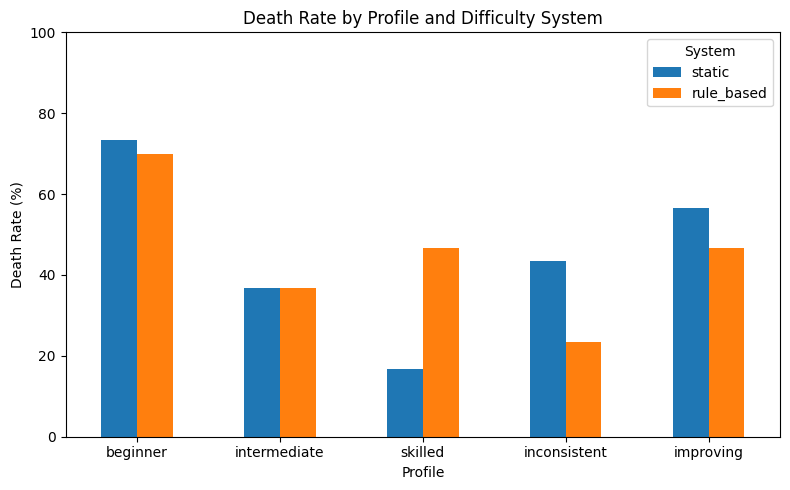

In [110]:
death_rate_pivot = system_summary.pivot(
    index="profile",
    columns="system_name",
    values="death_rate",
)

ax = death_rate_pivot.plot(kind="bar", figsize=(8, 5))

ax.set_title("Death Rate by Profile and Difficulty System")
ax.set_xlabel("Profile")
ax.set_ylabel("Death Rate (%)")
ax.set_ylim(0, 100)
ax.legend(title="System")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "death_rate_static_vs_rule_based.png", dpi=300)
plt.show()

### Interpretation

The death rate comparison shows how often each simulated player profile failed under static difficulty and rule-based DDA. This is one of the clearest indicators of gameplay balance because it directly shows whether the difficulty setting was too punishing or too easy for each profile.

Static difficulty produced different outcomes across profiles because the challenge level stayed fixed. Rule-based DDA changed the death rate for several profiles, showing that the adaptive system responded to gameplay conditions during the run. For weaker profiles, a lower death rate suggests that the system reduced excessive difficulty. For stronger profiles, a higher death rate can be useful because static difficulty was too easy for them.

This shows that rule-based DDA was more responsive than static difficulty, although it does not guarantee perfect balance for every profile.

### Average Survival Time

This chart compares average survival time for each simulated player profile under static difficulty and rule-based DDA.

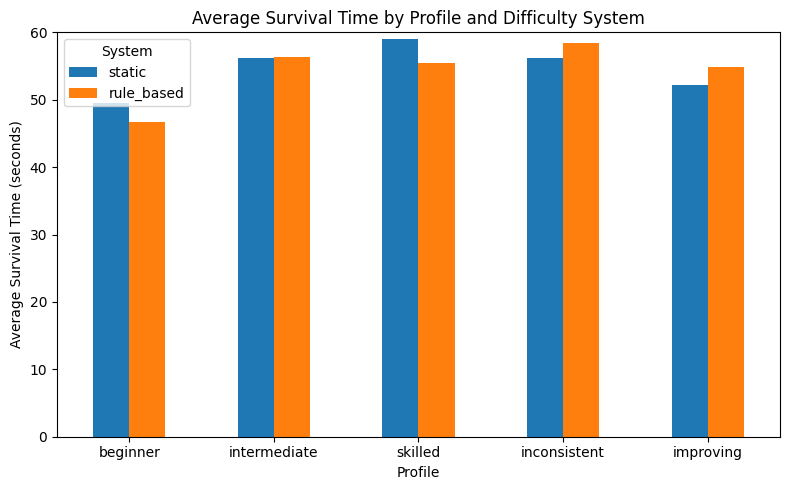

In [111]:
survival_pivot = system_summary.pivot(
    index="profile",
    columns="system_name",
    values="average_survival_time",
)

ax = survival_pivot.plot(kind="bar", figsize=(8, 5))

ax.set_title("Average Survival Time by Profile and Difficulty System")
ax.set_xlabel("Profile")
ax.set_ylabel("Average Survival Time (seconds)")
ax.set_ylim(0, 60)
ax.legend(title="System")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "average_survival_static_vs_rule_based.png", dpi=300)
plt.show()

### Interpretation

Average survival time shows how long each profile lasted under each difficulty system. In general, higher survival time means the profile performed better, while lower survival time suggests that the profile was under more pressure.

However, survival time must be interpreted carefully because each episode was capped at 60 seconds. This means many successful runs cluster near the maximum value, which can make differences between profiles look smaller than they are. For this reason, survival time is used alongside death rate, health remaining, hits taken, and difficulty changes.

The comparison still provides useful support for the death rate results by showing how the different systems affected overall run duration.

### Average Health Remaining

This chart compares average health remaining for each simulated player profile under static difficulty and rule-based DDA.

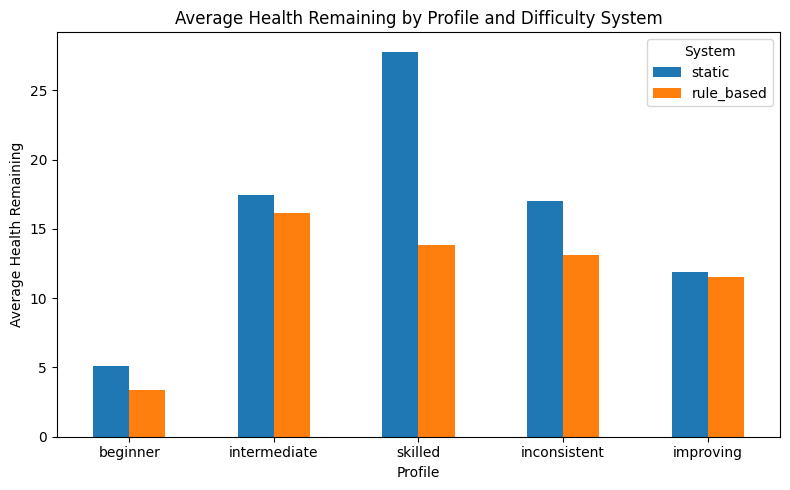

In [112]:
health_pivot = system_summary.pivot(
    index="profile",
    columns="system_name",
    values="average_health_remaining",
)

ax = health_pivot.plot(kind="bar", figsize=(8, 5))

ax.set_title("Average Health Remaining by Profile and Difficulty System")
ax.set_xlabel("Profile")
ax.set_ylabel("Average Health Remaining")
ax.legend(title="System")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "average_health_static_vs_rule_based.png", dpi=300)
plt.show()

### Interpretation

Average health remaining provides extra detail beyond survival time. A profile may survive a run, but low remaining health suggests that the run was still difficult. Higher remaining health suggests that the player was under less pressure.

This graph helps show whether each difficulty system created meaningful gameplay pressure. Static difficulty often left stronger profiles with higher health, suggesting that the fixed difficulty level was too easy for them. Rule-based DDA changed the amount of pressure experienced by different profiles by adjusting difficulty during the run.

This metric is useful because it shows not only whether the simulated player survived, but also how close the player was to failure.

### Average Difficulty

This chart compares the average difficulty experienced by each simulated player profile under both systems.

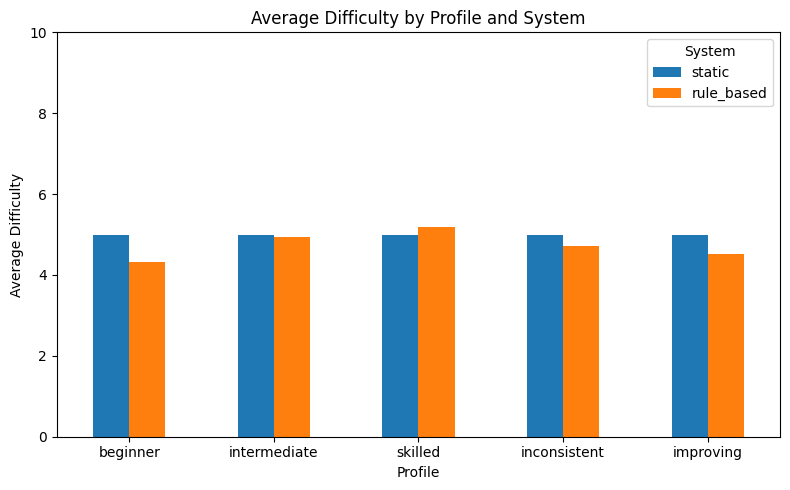

In [113]:
difficulty_pivot = system_summary.pivot(
    index="profile",
    columns="system_name",
    values="average_difficulty",
)

ax = difficulty_pivot.plot(kind="bar", figsize=(8, 5))

ax.set_title("Average Difficulty by Profile and System")
ax.set_xlabel("Profile")
ax.set_ylabel("Average Difficulty")
ax.set_ylim(0, 10)
ax.legend(title="System")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "average_difficulty_static_vs_rule_based.png", dpi=300)
plt.show()

### Interpretation

Average difficulty shows the average challenge level experienced by each profile during a run. For static difficulty, the average remains fixed at level 5 because the difficulty never changes. For rule-based DDA, the average difficulty can move above or below 5 depending on the player's performance.

This graph is important because it shows whether the adaptive system changed challenge differently for different profiles. Lower average difficulty suggests that the system reduced challenge for struggling profiles, while higher average difficulty suggests that it increased challenge for stronger profiles.

The result confirms that rule-based DDA did not simply copy the static baseline. It adjusted difficulty during gameplay, although the size of the adjustment depended on the manually designed rules.

### Difficulty Changes

This chart compares how often difficulty changed during runs for each simulated player profile under both systems.

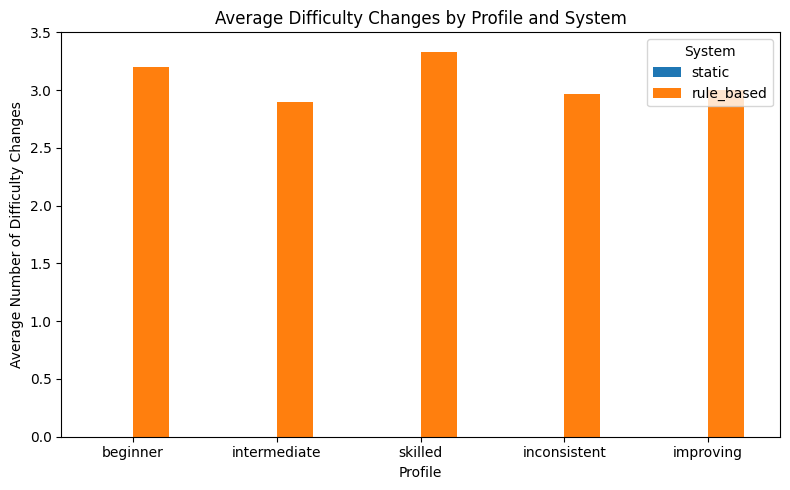

In [114]:
changes_pivot = system_summary.pivot(
    index="profile",
    columns="system_name",
    values="average_difficulty_changes",
)

ax = changes_pivot.plot(kind="bar", figsize=(8, 5))

ax.set_title("Average Difficulty Changes by Profile and System")
ax.set_xlabel("Profile")
ax.set_ylabel("Average Number of Difficulty Changes")
ax.legend(title="System")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "difficulty_changes_static_vs_rule_based.png", dpi=300)
plt.show()

### Interpretation

The difficulty changes graph shows how many times each system changed difficulty during a run. Static difficulty has zero changes because it remains fixed throughout the episode. Rule-based DDA has several changes per run, showing that the system actively adjusted difficulty during gameplay.

This graph is important because it confirms that the rule-based system was actually adaptive. The system was not only producing different final results; it was also changing the difficulty level during the run in response to player condition.

However, more difficulty changes are not always better. Too many changes could indicate unstable adaptation. Therefore, this metric should be interpreted alongside death rate, survival time, health remaining, and average difficulty.

### Death Rate Change from Static to Rule-Based DDA

This chart shows how the death rate changed when moving from static difficulty to rule-based DDA. Negative values mean that the rule-based system reduced deaths compared with static difficulty. Positive values mean that the rule-based system increased deaths, which can be useful for stronger profiles if static difficulty was too easy.

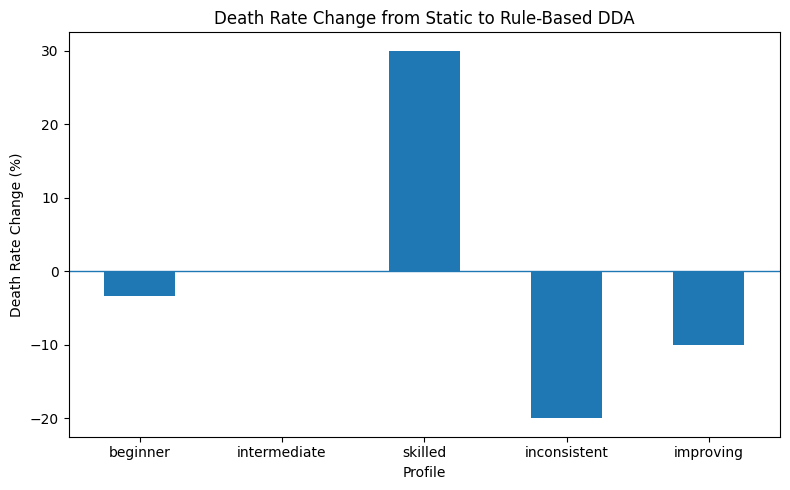

system_name,profile,static,rule_based,death_rate_change
0,beginner,73.33,70.00,-3.33
1,intermediate,36.67,36.67,0.00
2,skilled,16.67,46.67,30.00
3,inconsistent,43.33,23.33,-20.00
4,improving,56.67,46.67,-10.00


In [115]:
death_rate_change = system_summary.pivot(
    index="profile",
    columns="system_name",
    values="death_rate",
).reset_index()

death_rate_change["death_rate_change"] = (
    death_rate_change["rule_based"] - death_rate_change["static"]
)

ax = death_rate_change.plot(
    x="profile",
    y="death_rate_change",
    kind="bar",
    figsize=(8, 5),
    legend=False,
)

ax.axhline(0, linewidth=1)
ax.set_title("Death Rate Change from Static to Rule-Based DDA")
ax.set_xlabel("Profile")
ax.set_ylabel("Death Rate Change (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "death_rate_change_static_to_rule_based.png", dpi=300)
plt.show()

death_rate_change.round(2)

### Interpretation

This graph shows how death rate changed from static difficulty to rule-based DDA. Negative values mean deaths decreased, while positive values mean deaths increased.

The beginner, inconsistent, and improving profiles died less often under rule-based DDA, showing that the system reduced difficulty when needed. The skilled profile died more often, which is useful because static difficulty was too easy for that profile.

Overall, rule-based DDA changed the outcome differently for each profile instead of simply making the game easier for everyone.

### Rule-Based Difficulty Range by Profile

This chart shows the average minimum, average, and maximum difficulty reached by the rule-based DDA system for each profile. It helps show how much the system adjusted difficulty during gameplay.

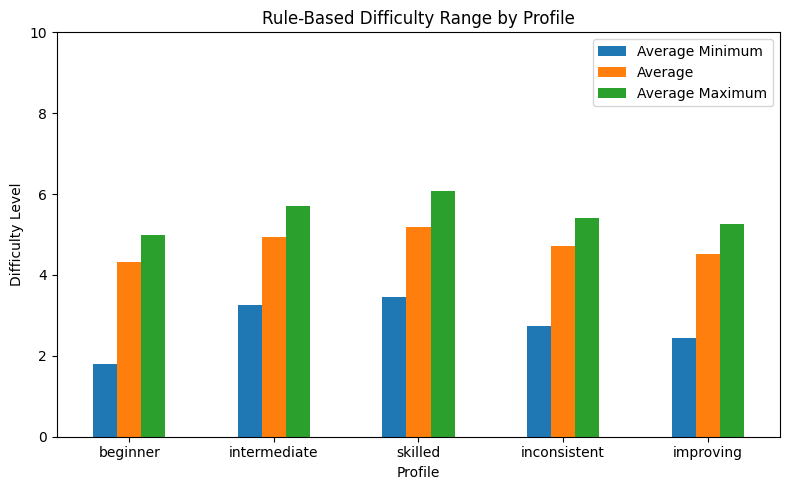

,profile,average_difficulty,average_min_difficulty,average_max_difficulty
5,beginner,4.31,1.80,5.00
6,intermediate,4.93,3.27,5.70
7,skilled,5.19,3.47,6.07
8,inconsistent,4.72,2.73,5.40
9,improving,4.52,2.43,5.27


In [116]:
rule_based_summary = system_summary[
    system_summary["system_name"] == "rule_based"
].copy()

difficulty_range = rule_based_summary[
    [
        "profile",
        "average_difficulty",
    ]
].copy()

difficulty_range["average_min_difficulty"] = (
    all_results[all_results["system_name"] == "rule_based"]
    .groupby("profile", observed=False)["min_difficulty"]
    .mean()
    .values
)

difficulty_range["average_max_difficulty"] = (
    all_results[all_results["system_name"] == "rule_based"]
    .groupby("profile", observed=False)["max_difficulty"]
    .mean()
    .values
)

ax = difficulty_range.plot(
    x="profile",
    y=[
        "average_min_difficulty",
        "average_difficulty",
        "average_max_difficulty",
    ],
    kind="bar",
    figsize=(8, 5),
)

ax.set_title("Rule-Based Difficulty Range by Profile")
ax.set_xlabel("Profile")
ax.set_ylabel("Difficulty Level")
ax.set_ylim(0, 10)
ax.legend(["Average Minimum", "Average", "Average Maximum"])
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "rule_based_difficulty_range_by_profile.png", dpi=300)
plt.show()

difficulty_range.round(2)

### Interpretation

This graph shows the minimum, average, and maximum difficulty reached by the rule-based DDA system. Unlike static difficulty, the rule-based system changed difficulty during gameplay.

The beginner profile generally experienced lower difficulty, while the skilled profile reached higher difficulty values. This shows that the system reduced challenge for weaker behaviour and increased challenge for stronger behaviour.

Overall, the graph confirms that rule-based DDA was actively adapting, although its behaviour was still limited by manually designed rules.

### Static vs Rule-Based DDA Interpretation

The comparison between static difficulty and rule-based DDA shows that the rule-based system actively changed the difficulty during gameplay, while the static system remained fixed. This is shown most clearly by the difficulty changes graph, where static difficulty has zero changes and rule-based DDA has several changes per run on average.

The death rate graph shows that rule-based DDA affected different profiles in different ways. The skilled profile became more challenged under rule-based DDA, suggesting that the system increased pressure for stronger simulated behaviour. The beginner and improving profiles also changed compared with the static baseline, although the size of the improvement varied between profiles.

Average survival time was less clear because each episode was capped at 60 seconds, meaning many runs clustered near the maximum duration. For this reason, survival time was interpreted alongside death rate, health remaining, average difficulty, and difficulty changes.

The average difficulty graph shows that the rule-based system adjusted challenge around the starting difficulty level of 5. Weaker or struggling profiles tended to have lower average difficulty, while stronger profiles could experience higher average difficulty. This confirms that the rule-based system responded to gameplay conditions rather than behaving like a fixed difficulty setting.

Overall, the rule-based DDA system provided a useful adaptive baseline. It was more responsive than static difficulty, but its behaviour was still limited by manually designed thresholds. This makes it a suitable comparison point for the later RL-based DDA system.

In [117]:
system_summary[
    ["system_name", "profile", "runs", "deaths", "survivals", "death_rate"]
].round(2)

,system_name,profile,runs,deaths,survivals,death_rate
0,static,beginner,30,22,8,73.33
1,static,intermediate,30,11,19,36.67
2,static,skilled,30,5,25,16.67
3,static,inconsistent,30,13,17,43.33
4,static,improving,30,17,13,56.67
5,rule_based,beginner,30,21,9,70.00
6,rule_based,intermediate,30,11,19,36.67
7,rule_based,skilled,30,14,16,46.67
8,rule_based,inconsistent,30,7,23,23.33
9,rule_based,improving,30,14,16,46.67


## 6. Load Final RL-Based DDA Results

This section adds the final RL-based DDA evaluation results to the existing static and rule-based datasets.

The final RL evaluation uses stochastic PPO action sampling. Each simulated player profile was evaluated for 30 runs, matching the number of runs used for the static and rule-based systems.

The five evaluated profiles are beginner, intermediate, skilled, inconsistent, and improving.

In [118]:
RL_FILES = {
    "beginner": "rl_based_beginner_logged.csv",
    "intermediate": "rl_based_intermediate_logged.csv",
    "skilled": "rl_based_skilled_logged.csv",
    "inconsistent": "rl_based_inconsistent_logged.csv",
    "improving": "rl_based_improving_logged.csv",
}

SYSTEM_FILES["rl_based"] = RL_FILES

SYSTEM_ORDER = [
    "static",
    "rule_based",
    "rl_based",
]

FINAL_COMBINED_DATA_PATH = (
    PROCESSED_DATA_DIR / "final_difficulty_systems_combined.csv"
)

frames = []

for system_name, profile_files in SYSTEM_FILES.items():
    for profile, file_name in profile_files.items():
        file_path = RAW_DATA_DIR / file_name

        if not file_path.exists():
            print(f"Missing file: {file_path}")
            continue

        df = pd.read_csv(file_path)

        # Remove accidental saved dataframe indices if present.
        unwanted_columns = [
            column
            for column in df.columns
            if column == "index" or column.startswith("Unnamed:")
        ]

        if unwanted_columns:
            df = df.drop(columns=unwanted_columns)

        df["system_name"] = system_name
        df["profile"] = profile

        frames.append(df)

all_results = pd.concat(frames, ignore_index=True)

all_results["player_died"] = (
    all_results["player_died"]
    .astype(str)
    .str.lower()
    .isin(["true", "1", "yes"])
)

numeric_columns = [
    "run_number",
    "survival_time",
    "score",
    "health_remaining",
    "hits_taken",
    "deaths",
    "initial_difficulty",
    "final_difficulty",
    "average_difficulty",
    "min_difficulty",
    "max_difficulty",
    "difficulty_changes",
    "time_in_target_range",
    "target_range_percentage",
    "profile_speed",
    "profile_reaction_time",
    "profile_dodge_chance",
    "profile_mistake_chance",
    "profile_detection_radius",
    "profile_dodge_duration",
    "profile_strafe_weight",
    "profile_retreat_weight",
]

for column in numeric_columns:
    if column in all_results.columns:
        all_results[column] = pd.to_numeric(
            all_results[column],
            errors="coerce",
        )

all_results["profile"] = pd.Categorical(
    all_results["profile"],
    categories=PROFILE_ORDER,
    ordered=True,
)

all_results["system_name"] = pd.Categorical(
    all_results["system_name"],
    categories=SYSTEM_ORDER,
    ordered=True,
)

all_results = all_results.sort_values(
    ["system_name", "profile", "run_number"]
).reset_index(drop=True)

all_results.to_csv(
    FINAL_COMBINED_DATA_PATH,
    index=False,
)

FINAL_COMBINED_DATA_PATH

PosixPath('../data/processed/final_difficulty_systems_combined.csv')

### Final Dataset Validation

Each system should contain exactly 30 runs for each simulated player profile.

This gives 150 evaluation runs per difficulty system and 450 final evaluation runs overall.

In [119]:
run_counts = (
    all_results
    .groupby(
        ["system_name", "profile"],
        observed=False,
    )
    .size()
    .unstack()
)

assert (run_counts == 30).all().all(), (
    "One or more final experiment conditions do not contain 30 runs."
)

print(f"Total final evaluation runs: {len(all_results)}")

run_counts

Total final evaluation runs: 450


profile,beginner,intermediate,skilled,inconsistent,improving
system_name,,,,,
static,30,30,30,30,30
rule_based,30,30,30,30,30
rl_based,30,30,30,30,30


## 7. RL-Based DDA Results

This section examines the final RL-based DDA system separately before comparing it with the two baseline systems.

The RL controller was evaluated using stochastic PPO action sampling. Unlike the deterministic evaluation tested during development, the stochastic policy continued to make difficulty adjustments throughout the episodes and therefore represented the adaptive behaviour learned during training.

In [120]:
rl_results = all_results[
    all_results["system_name"] == "rl_based"
].copy()

rl_summary = (
    rl_results
    .groupby("profile", observed=False)
    .agg(
        runs=("run_number", "count"),
        deaths=("player_died", "sum"),
        average_survival_time=("survival_time", "mean"),
        median_survival_time=("survival_time", "median"),
        average_health_remaining=("health_remaining", "mean"),
        average_hits_taken=("hits_taken", "mean"),
        average_difficulty=("average_difficulty", "mean"),
        average_final_difficulty=("final_difficulty", "mean"),
        average_difficulty_changes=("difficulty_changes", "mean"),
        average_target_range_percentage=(
            "target_range_percentage",
            "mean",
        ),
    )
    .reset_index()
)

rl_summary["survivals"] = (
    rl_summary["runs"] - rl_summary["deaths"]
)

rl_summary["death_rate"] = (
    rl_summary["deaths"] / rl_summary["runs"]
) * 100

rl_summary["survival_rate"] = (
    rl_summary["survivals"] / rl_summary["runs"]
) * 100

rl_summary = rl_summary[
    [
        "profile",
        "runs",
        "deaths",
        "survivals",
        "death_rate",
        "survival_rate",
        "average_survival_time",
        "median_survival_time",
        "average_health_remaining",
        "average_hits_taken",
        "average_difficulty",
        "average_final_difficulty",
        "average_difficulty_changes",
        "average_target_range_percentage",
    ]
]

rl_summary.round(2)

,profile,runs,deaths,survivals,death_rate,survival_rate,average_survival_time,median_survival_time,average_health_remaining,average_hits_taken,average_difficulty,average_final_difficulty,average_difficulty_changes,average_target_range_percentage
0,beginner,30,15,15,50.00,50.00,46.80,58.75,14.49,11.20,3.55,2.50,12.17,49.86
1,intermediate,30,4,26,13.33,86.67,57.36,60.00,45.56,6.07,3.52,1.77,13.30,48.31
2,skilled,30,8,22,26.67,73.33,52.55,60.00,41.47,6.30,4.01,2.47,12.20,39.89
3,inconsistent,30,13,17,43.33,56.67,48.95,60.00,22.02,9.13,4.10,2.43,12.50,49.52
4,improving,30,7,23,23.33,76.67,57.10,60.00,30.73,8.37,3.57,1.73,13.93,55.42


### RL Summary

The following output provides a concise summary of the final RL evaluation for each simulated player profile.

In [121]:
for _, row in rl_summary.iterrows():
    print(
        f"{row['profile']}: "
        f"{int(row['deaths'])}/{int(row['runs'])} deaths "
        f"({row['death_rate']:.1f}% death rate), "
        f"average survival = {row['average_survival_time']:.2f}s, "
        f"average difficulty = {row['average_difficulty']:.2f}, "
        f"difficulty changes = {row['average_difficulty_changes']:.2f}, "
        f"target range = {row['average_target_range_percentage']:.2f}%."
    )

beginner: 15/30 deaths (50.0% death rate), average survival = 46.80s, average difficulty = 3.55, difficulty changes = 12.17, target range = 49.86%.
intermediate: 4/30 deaths (13.3% death rate), average survival = 57.36s, average difficulty = 3.52, difficulty changes = 13.30, target range = 48.31%.
skilled: 8/30 deaths (26.7% death rate), average survival = 52.55s, average difficulty = 4.01, difficulty changes = 12.20, target range = 39.89%.
inconsistent: 13/30 deaths (43.3% death rate), average survival = 48.95s, average difficulty = 4.10, difficulty changes = 12.50, target range = 49.52%.
improving: 7/30 deaths (23.3% death rate), average survival = 57.10s, average difficulty = 3.57, difficulty changes = 13.93, target range = 55.42%.


## 8. Static, Rule-Based and RL-Based Comparison

The final comparison includes all three difficulty systems.

Performance is evaluated using multiple objective metrics rather than a single measure. Death rate and survival time indicate whether difficulty became excessively punishing, while average difficulty and difficulty changes show how the adaptive systems behaved during each episode.

Target-range percentage is compared only between rule-based and RL-based DDA because this metric was not recorded during the original static baseline experiment.

In [122]:
system_summary = (
    all_results
    .groupby(
        ["system_name", "profile"],
        observed=False,
    )
    .agg(
        runs=("run_number", "count"),
        deaths=("player_died", "sum"),
        average_survival_time=("survival_time", "mean"),
        median_survival_time=("survival_time", "median"),
        average_health_remaining=("health_remaining", "mean"),
        average_hits_taken=("hits_taken", "mean"),
        average_difficulty=("average_difficulty", "mean"),
        average_final_difficulty=("final_difficulty", "mean"),
        average_difficulty_changes=("difficulty_changes", "mean"),
        average_target_range_percentage=(
            "target_range_percentage",
            "mean",
        ),
    )
    .reset_index()
)

system_summary["survivals"] = (
    system_summary["runs"] - system_summary["deaths"]
)

system_summary["death_rate"] = (
    system_summary["deaths"] / system_summary["runs"]
) * 100

system_summary["survival_rate"] = (
    system_summary["survivals"] / system_summary["runs"]
) * 100

system_summary = system_summary[
    [
        "system_name",
        "profile",
        "runs",
        "deaths",
        "survivals",
        "death_rate",
        "survival_rate",
        "average_survival_time",
        "median_survival_time",
        "average_health_remaining",
        "average_hits_taken",
        "average_difficulty",
        "average_final_difficulty",
        "average_difficulty_changes",
        "average_target_range_percentage",
    ]
]

system_summary.round(2)

,system_name,profile,runs,deaths,survivals,death_rate,survival_rate,average_survival_time,median_survival_time,average_health_remaining,average_hits_taken,average_difficulty,average_final_difficulty,average_difficulty_changes,average_target_range_percentage
0,static,beginner,30,22,8,73.33,26.67,49.45,52.25,5.13,11.33,5.00,5.00,0.00,NaN
1,static,intermediate,30,11,19,36.67,63.33,56.26,60.00,17.43,9.80,5.00,5.00,0.00,NaN
2,static,skilled,30,5,25,16.67,83.33,59.06,60.00,27.80,8.53,5.00,5.00,0.00,NaN
3,static,inconsistent,30,13,17,43.33,56.67,56.20,60.00,17.00,9.87,5.00,5.00,0.00,NaN
4,static,improving,30,17,13,56.67,43.33,52.22,59.21,11.88,10.50,5.00,5.00,0.00,NaN
5,rule_based,beginner,30,21,9,70.00,30.00,46.68,49.50,3.38,12.13,4.31,1.80,3.20,47.32
6,rule_based,intermediate,30,11,19,36.67,63.33,56.27,60.00,16.16,9.37,4.93,3.50,2.90,48.78
7,rule_based,skilled,30,14,16,46.67,53.33,55.41,60.00,13.85,9.40,5.19,3.80,3.33,46.96
8,rule_based,inconsistent,30,7,23,23.33,76.67,58.44,60.00,13.11,10.13,4.72,2.83,2.97,50.06
9,rule_based,improving,30,14,16,46.67,53.33,54.82,60.00,11.51,10.63,4.52,2.53,3.00,46.40


In [123]:
final_summary_path = (
    TABLE_DIR / "static_rule_rl_summary.csv"
)

system_summary.round(2).to_csv(
    final_summary_path,
    index=False,
)

final_summary_path

PosixPath('../results/tables/static_rule_rl_summary.csv')

### Death Rate Across All Difficulty Systems

This graph compares failure rate across the static, rule-based, and RL-based systems.

Death rate is interpreted as one indicator of gameplay balance. A high death rate suggests excessive challenge, while an extremely low death rate can indicate insufficient challenge. It is therefore interpreted alongside the other gameplay metrics.

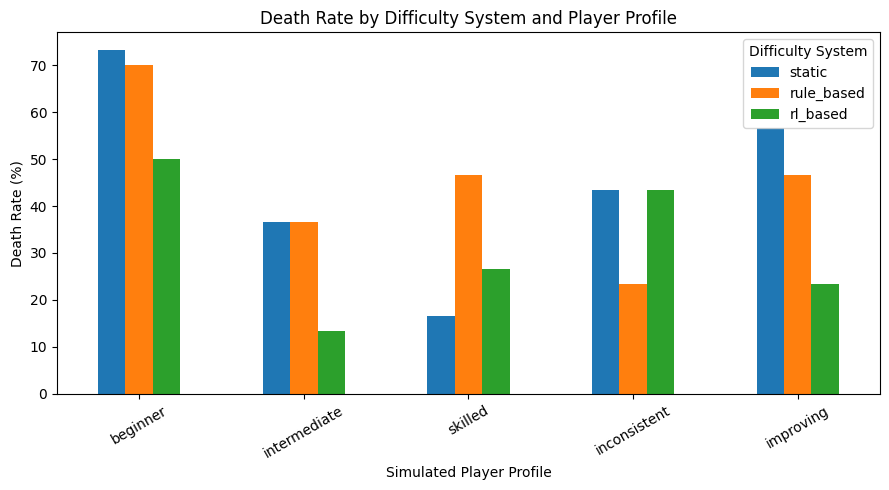

In [124]:
death_rate_plot = (
    system_summary
    .pivot(
        index="profile",
        columns="system_name",
        values="death_rate",
    )
    .reindex(PROFILE_ORDER)
)

death_rate_plot.plot(
    kind="bar",
    figsize=(9, 5),
)

plt.title("Death Rate by Difficulty System and Player Profile")
plt.xlabel("Simulated Player Profile")
plt.ylabel("Death Rate (%)")
plt.xticks(rotation=30)
plt.legend(title="Difficulty System")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "all_systems_death_rate.png",
    dpi=300,
)

plt.show()

### Interpretation

RL substantially reduces deaths for the beginner, intermediate, and improving profiles compared with both baselines. It also improves on rule-based DDA for the skilled profile, but performs poorly for the inconsistent profile compared with the rule-based system.

### Average Survival Time Across All Difficulty Systems

Survival time provides a second measure of difficulty balance. However, episodes were capped at 60 seconds, meaning many successful runs have the same maximum survival value. Survival time is therefore interpreted alongside death rate, remaining health, and other metrics rather than on its own.

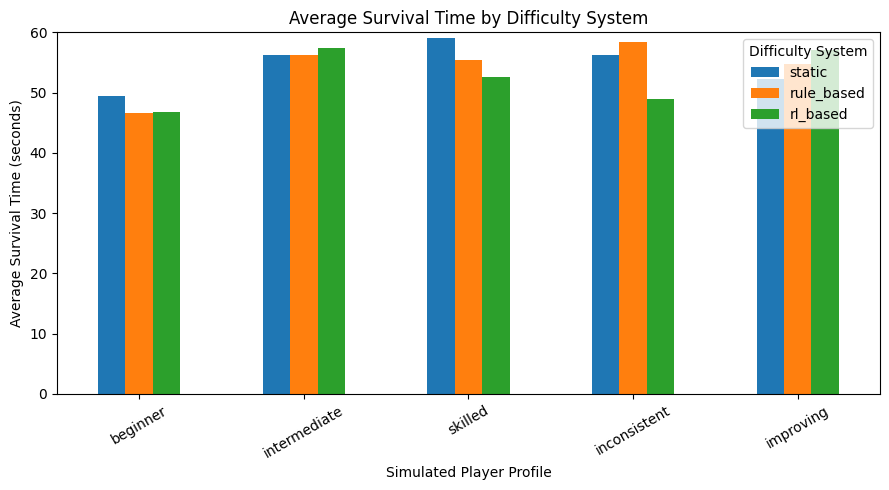

In [125]:
survival_plot = (
    system_summary
    .pivot(
        index="profile",
        columns="system_name",
        values="average_survival_time",
    )
    .reindex(PROFILE_ORDER)
)

survival_plot.plot(
    kind="bar",
    figsize=(9, 5),
)

plt.title("Average Survival Time by Difficulty System")
plt.xlabel("Simulated Player Profile")
plt.ylabel("Average Survival Time (seconds)")
plt.ylim(0, 60)
plt.xticks(rotation=30)
plt.legend(title="Difficulty System")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "all_systems_average_survival.png",
    dpi=300,
)

plt.show()

### Interpretation

RL produces similar or improved survival for the beginner, intermediate, and improving profiles, but lower survival for skilled and inconsistent profiles. This shows that its effect varies depending on simulated player behaviour.

### Average Difficulty

Average difficulty shows the challenge level experienced throughout each episode.

Static difficulty remains fixed at level 5. Rule-based and RL-based DDA can move above or below the starting difficulty in response to simulated gameplay performance.

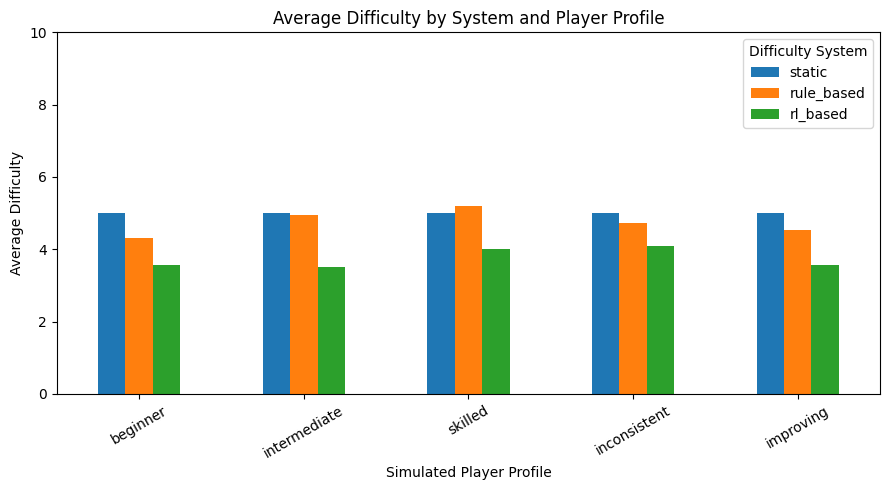

In [126]:
average_difficulty_plot = (
    system_summary
    .pivot(
        index="profile",
        columns="system_name",
        values="average_difficulty",
    )
    .reindex(PROFILE_ORDER)
)

average_difficulty_plot.plot(
    kind="bar",
    figsize=(9, 5),
)

plt.title("Average Difficulty by System and Player Profile")
plt.xlabel("Simulated Player Profile")
plt.ylabel("Average Difficulty")
plt.ylim(0, 10)
plt.xticks(rotation=30)
plt.legend(title="Difficulty System")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "all_systems_average_difficulty.png",
    dpi=300,
)

plt.show()

### Interpretation

RL maintains a lower average difficulty than both static and rule-based systems across all profiles. This suggests that the learned policy generally favours reducing challenge rather than maintaining difficulty near the initial level of 5.

### Difficulty Changes

This graph compares the amount of adaptation performed during each episode.

Static difficulty always produces zero changes. Rule-based and RL-based DDA actively modify difficulty during gameplay. A larger number of changes does not automatically mean better performance, because excessive adjustment could also indicate instability.

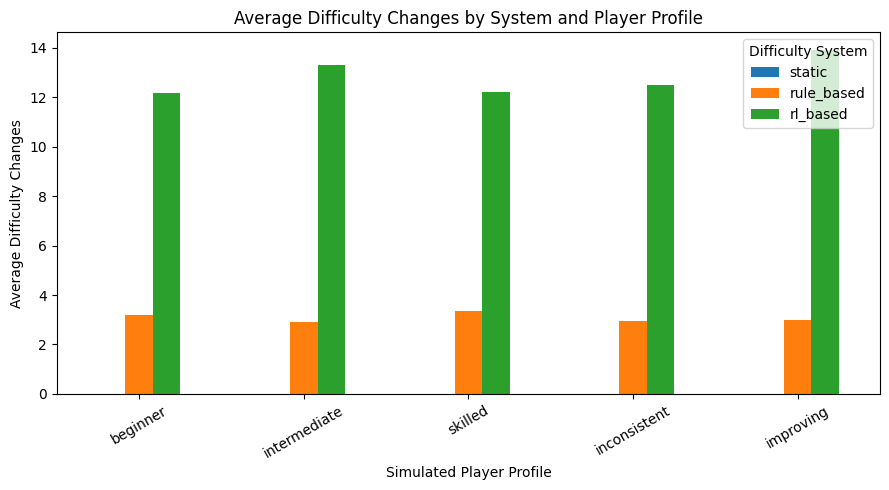

In [127]:
difficulty_changes_plot = (
    system_summary
    .pivot(
        index="profile",
        columns="system_name",
        values="average_difficulty_changes",
    )
    .reindex(PROFILE_ORDER)
)

difficulty_changes_plot.plot(
    kind="bar",
    figsize=(9, 5),
)

plt.title("Average Difficulty Changes by System and Player Profile")
plt.xlabel("Simulated Player Profile")
plt.ylabel("Average Difficulty Changes")
plt.xticks(rotation=30)
plt.legend(title="Difficulty System")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "all_systems_difficulty_changes.png",
    dpi=300,
)

plt.show()

### Interpretation

RL makes substantially more difficulty adjustments than the rule-based system across every profile. This confirms that the stochastic RL policy is much more reactive, although a higher number of changes does not necessarily mean better balance.

### Target Balance Range: Rule-Based vs RL-Based DDA

Target-range percentage measures the proportion of each episode during which simulated player health remained within the predefined target balance range.

This value was logged during the rule-based and RL-based experiments. It was not available for the original static baseline runs, so the comparison below includes only the two adaptive systems.

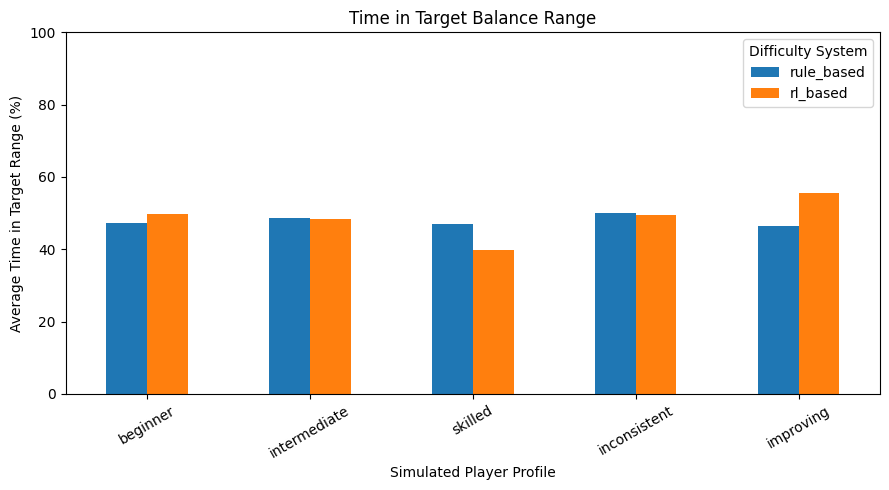

In [128]:
adaptive_summary = system_summary[
    system_summary["system_name"].isin(
        ["rule_based", "rl_based"]
    )
].copy()

target_range_plot = (
    adaptive_summary
    .pivot(
        index="profile",
        columns="system_name",
        values="average_target_range_percentage",
    )
    .reindex(PROFILE_ORDER)
)

target_range_plot.plot(
    kind="bar",
    figsize=(9, 5),
)

plt.title("Time in Target Balance Range")
plt.xlabel("Simulated Player Profile")
plt.ylabel("Average Time in Target Range (%)")
plt.ylim(0, 100)
plt.xticks(rotation=30)
plt.legend(title="Difficulty System")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rule_vs_rl_target_range.png",
    dpi=300,
)

plt.show()

### Interpretation

RL performs similarly to rule-based DDA for most profiles, with better target-range performance for the beginner and especially improving profiles. However, it performs noticeably worse for the skilled profile.

### Target-Range Distribution

The mean target-range percentage shows overall performance, but it does not show how much individual runs vary.

This boxplot compares the distribution of target-range occupancy for rule-based and RL-based DDA across each simulated player profile. Static difficulty is excluded because target-range percentage was not logged during the original static baseline experiment.

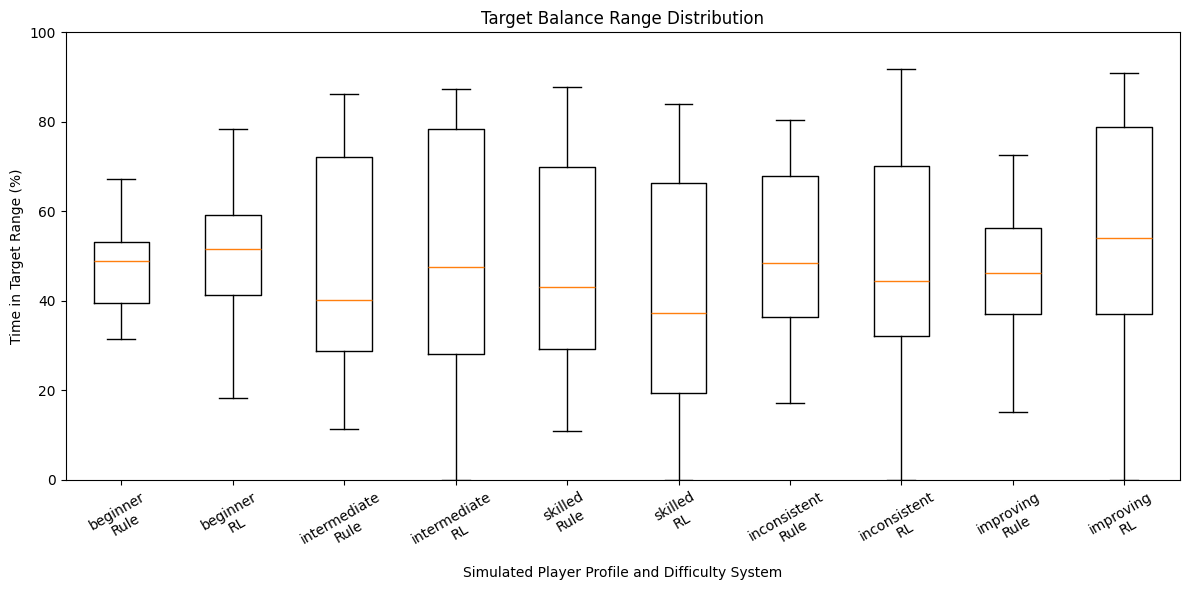

In [129]:
adaptive_results = all_results[
    all_results["system_name"].isin(
        ["rule_based", "rl_based"]
    )
].copy()

boxplot_data = []
boxplot_labels = []

for profile in PROFILE_ORDER:
    for system_name in ["rule_based", "rl_based"]:
        values = adaptive_results[
            (adaptive_results["profile"] == profile)
            & (adaptive_results["system_name"] == system_name)
        ]["target_range_percentage"].dropna()

        boxplot_data.append(values)

        system_label = (
            "Rule"
            if system_name == "rule_based"
            else "RL"
        )

        boxplot_labels.append(
            f"{profile}\n{system_label}"
        )

plt.figure(figsize=(12, 6))

plt.boxplot(
    boxplot_data,
    tick_labels=boxplot_labels,
)

plt.title("Target Balance Range Distribution")
plt.xlabel("Simulated Player Profile and Difficulty System")
plt.ylabel("Time in Target Range (%)")
plt.ylim(0, 100)
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "target_range_distribution.png",
    dpi=300,
)

plt.show()

### Interpretation

Both adaptive systems show substantial variation in target-range occupancy between episodes. RL has wider distributions for several profiles, indicating less consistent behaviour, while producing a higher median for the improving profile and a lower median for the skilled profile.

### RL Difficulty Range by Profile

Average difficulty alone does not show the full range of challenge levels visited by the RL controller.

This graph compares the mean minimum, episode-average, and mean maximum difficulty reached for each simulated player profile.

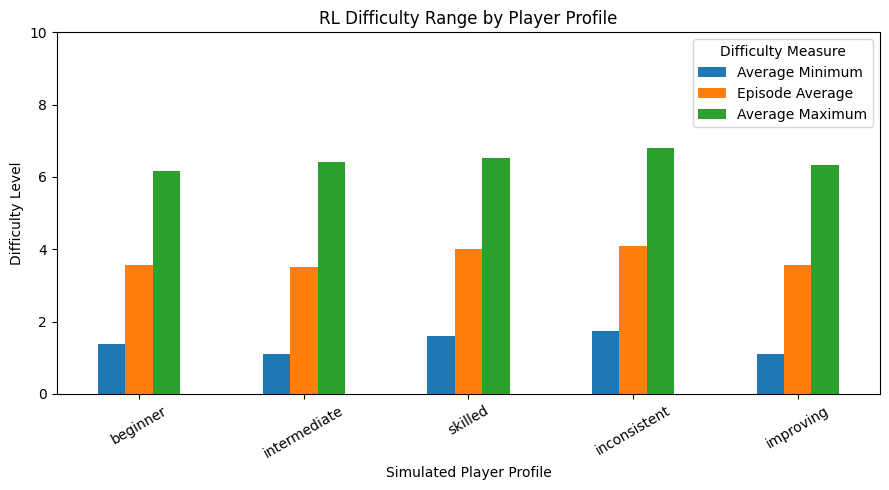

,average_minimum_difficulty,average_difficulty,average_maximum_difficulty
profile,,,
beginner,1.37,3.55,6.17
intermediate,1.10,3.52,6.40
skilled,1.60,4.01,6.53
inconsistent,1.73,4.10,6.80
improving,1.10,3.57,6.33


In [130]:
rl_difficulty_range = (
    rl_results
    .groupby("profile", observed=False)
    .agg(
        average_minimum_difficulty=(
            "min_difficulty",
            "mean",
        ),
        average_difficulty=(
            "average_difficulty",
            "mean",
        ),
        average_maximum_difficulty=(
            "max_difficulty",
            "mean",
        ),
    )
    .reindex(PROFILE_ORDER)
)

rl_difficulty_range.plot(
    kind="bar",
    figsize=(9, 5),
)

plt.title("RL Difficulty Range by Player Profile")
plt.xlabel("Simulated Player Profile")
plt.ylabel("Difficulty Level")
plt.ylim(0, 10)
plt.xticks(rotation=30)
plt.legend(
    [
        "Average Minimum",
        "Episode Average",
        "Average Maximum",
    ],
    title="Difficulty Measure",
)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rl_difficulty_range_by_profile.png",
    dpi=300,
)

plt.show()

rl_difficulty_range.round(2)

### Interpretation

The RL policy explores a broad difficulty range for every player profile, typically reaching minimum values around 1–2 and maximum values around 6–7 despite maintaining episode averages around 3.5–4.1. This demonstrates that its low average difficulty does not result from selecting one fixed low difficulty level.

## 9. Improving Player Profile

The improving profile gradually changes from weaker simulated behaviour toward stronger behaviour across the 30 experiment runs.

This provides a useful test of adaptation because the difficulty system must respond to a player whose performance characteristics change over time rather than remaining fixed.

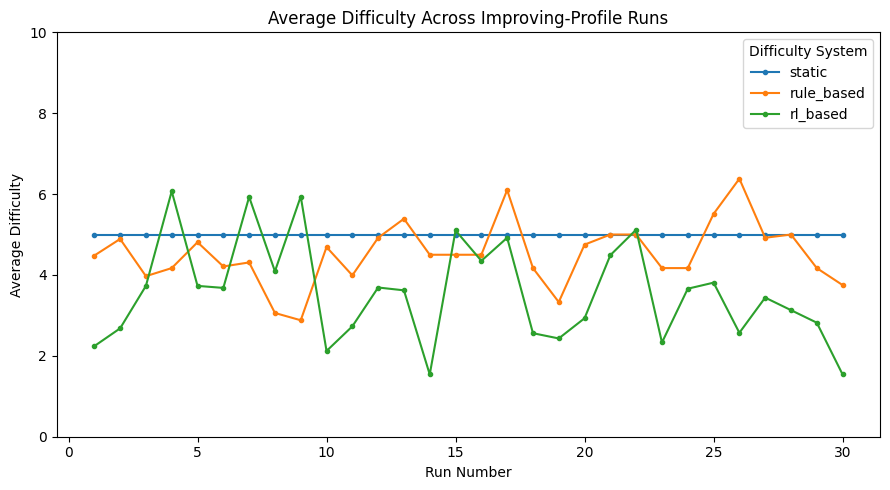

In [131]:
improving_results = all_results[
    all_results["profile"] == "improving"
].copy()

plt.figure(figsize=(9, 5))

for system_name in SYSTEM_ORDER:
    system_data = improving_results[
        improving_results["system_name"] == system_name
    ].sort_values("run_number")

    plt.plot(
        system_data["run_number"],
        system_data["average_difficulty"],
        marker="o",
        markersize=3,
        label=system_name,
    )

plt.title("Average Difficulty Across Improving-Profile Runs")
plt.xlabel("Run Number")
plt.ylabel("Average Difficulty")
plt.ylim(0, 10)
plt.legend(title="Difficulty System")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "improving_profile_difficulty_over_time.png",
    dpi=300,
)

plt.show()

### Interpretation

The static system remains fixed at difficulty 5, while both adaptive systems vary across runs. RL shows greater variability and generally lower difficulty, but does not show a clear upward trend as the simulated player improves.

In [132]:
import numpy as np

improving_trends = []

for system_name in SYSTEM_ORDER:
    system_data = improving_results[
        improving_results["system_name"] == system_name
    ].sort_values("run_number")

    difficulty_slope = np.polyfit(
        system_data["run_number"],
        system_data["average_difficulty"],
        1,
    )[0]

    improving_trends.append(
        {
            "system_name": system_name,
            "difficulty_change_per_run": difficulty_slope,
        }
    )

improving_trends = pd.DataFrame(improving_trends)

improving_trends.round(3)

,system_name,difficulty_change_per_run
0,static,0.000
1,rule_based,0.022
2,rl_based,-0.037


### Improving Profile Survival Trend

The improving profile gradually changes from beginner-like to stronger behaviour across the 30 runs.

A five-run rolling average is used to reduce individual episode noise and show the broader survival trend under each difficulty system.

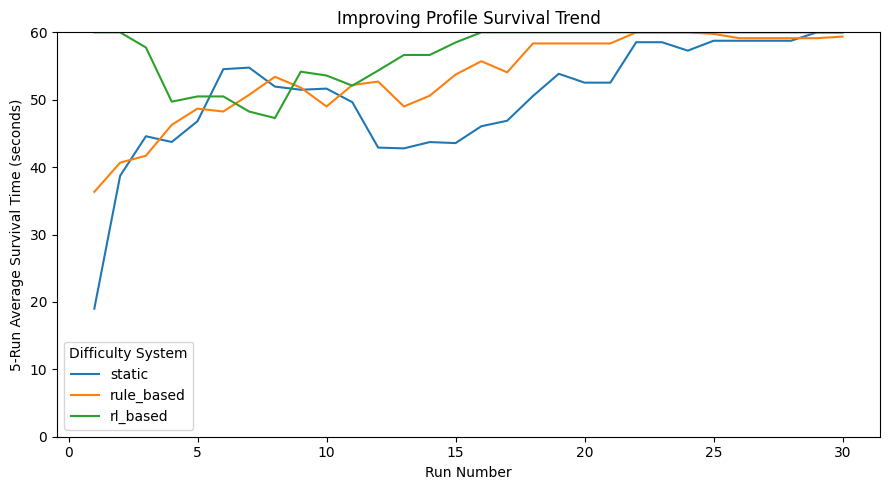

In [133]:
improving_results = all_results[
    all_results["profile"] == "improving"
].copy()

plt.figure(figsize=(9, 5))

for system_name in SYSTEM_ORDER:
    system_data = (
        improving_results[
            improving_results["system_name"] == system_name
        ]
        .sort_values("run_number")
        .copy()
    )

    system_data["rolling_survival"] = (
        system_data["survival_time"]
        .rolling(
            window=5,
            min_periods=1,
        )
        .mean()
    )

    plt.plot(
        system_data["run_number"],
        system_data["rolling_survival"],
        label=system_name,
    )

plt.title("Improving Profile Survival Trend")
plt.xlabel("Run Number")
plt.ylabel("5-Run Average Survival Time (seconds)")
plt.ylim(0, 60)
plt.legend(title="Difficulty System")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "improving_profile_survival_trend.png",
    dpi=300,
)

plt.show()

### Interpretation

All systems generally converge toward long survival times as the simulated player improves. RL initially maintains high survival, drops during the middle portion of the progression, and then returns to near-maximum survival, showing that its response to the changing profile is not monotonic.

### Distance from a 50% Failure Rate

A medium difficulty condition was intended to produce mixed success and failure rather than either near-certain survival or near-certain death.

As a supplementary measure, this graph shows the absolute distance between each observed death rate and a 50% failure rate. A smaller value indicates an outcome closer to an even mixture of successful and failed episodes.

This measure is used only as supporting evidence and does not replace the target-range and gameplay-performance measures used elsewhere in the analysis.

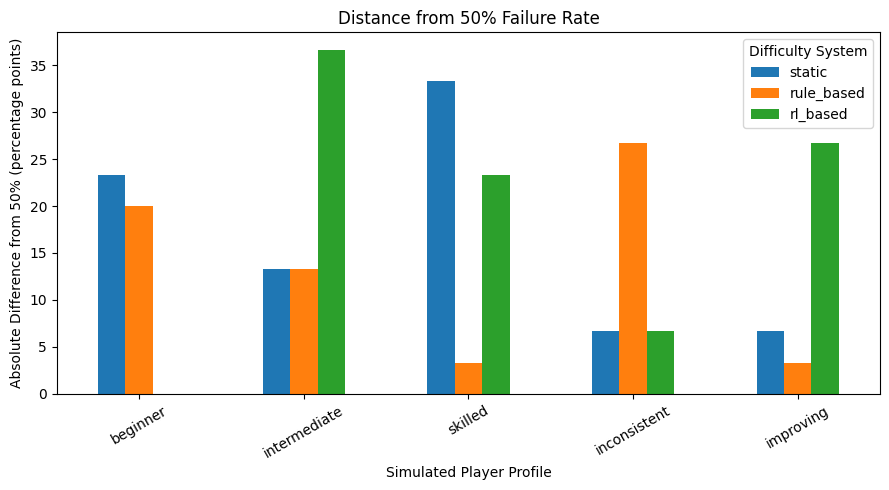

In [134]:
balance_distance = system_summary[
    [
        "system_name",
        "profile",
        "death_rate",
    ]
].copy()

balance_distance["distance_from_50"] = (
    balance_distance["death_rate"] - 50
).abs()

distance_plot = (
    balance_distance
    .pivot(
        index="profile",
        columns="system_name",
        values="distance_from_50",
    )
    .reindex(PROFILE_ORDER)
)

distance_plot.plot(
    kind="bar",
    figsize=(9, 5),
)

plt.title("Distance from 50% Failure Rate")
plt.xlabel("Simulated Player Profile")
plt.ylabel(
    "Absolute Difference from 50% "
    "(percentage points)"
)
plt.xticks(rotation=30)
plt.legend(title="Difficulty System")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "distance_from_50_death_rate.png",
    dpi=300,
)

plt.show()

### Interpretation

No single system remains consistently closest to a 50% failure rate across every profile. RL is relatively close for the beginner and inconsistent profiles, but substantially further away for intermediate and improving players.

This is treated as supplementary analysis because a 50% failure rate is a convenient operational reference rather than the primary definition of gameplay balance.

## RL Policy Diagnostics

### RL Reactivity and Failure Rate

To examine whether the amount of RL adaptation is associated with gameplay outcomes, episodes are grouped according to the number of difficulty changes made during the run.

This is an exploratory association and does not establish that making more difficulty changes directly causes lower or higher failure rates.

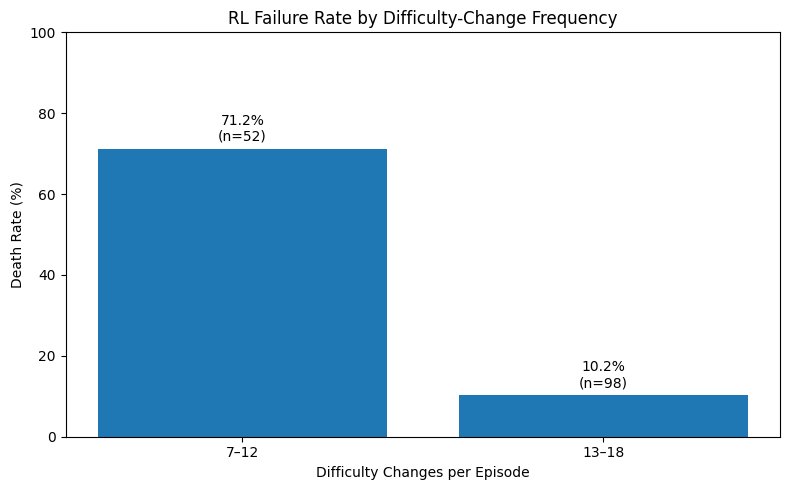

,change_group,episodes,deaths,death_rate,average_survival
0,0–6,0,0,NaN,NaN
1,7–12,52,37,71.15,40.37
2,13–18,98,10,10.20,59.01
3,19+,0,0,NaN,NaN


In [135]:
rl_reactivity = rl_results.copy()

rl_reactivity["change_group"] = pd.cut(
    rl_reactivity["difficulty_changes"],
    bins=[
        -1,
        6,
        12,
        18,
        float("inf"),
    ],
    labels=[
        "0–6",
        "7–12",
        "13–18",
        "19+",
    ],
)

reactivity_summary = (
    rl_reactivity
    .groupby(
        "change_group",
        observed=False,
    )
    .agg(
        episodes=("run_number", "count"),
        deaths=("player_died", "sum"),
        death_rate=("player_died", "mean"),
        average_survival=(
            "survival_time",
            "mean",
        ),
    )
    .reset_index()
)

reactivity_summary["death_rate"] *= 100

plt.figure(figsize=(8, 5))

bars = plt.bar(
    reactivity_summary["change_group"].astype(str),
    reactivity_summary["death_rate"],
)

plt.title("RL Failure Rate by Difficulty-Change Frequency")
plt.xlabel("Difficulty Changes per Episode")
plt.ylabel("Death Rate (%)")
plt.ylim(0, 100)

for bar, row in zip(
    bars,
    reactivity_summary.itertuples(),
):
    if row.episodes > 0:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            row.death_rate + 2,
            f"{row.death_rate:.1f}%\n(n={row.episodes})",
            ha="center",
        )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rl_reactivity_vs_death_rate.png",
    dpi=300,
)

plt.show()

reactivity_summary.round(2)

### Interpretation

Episodes with 7–12 difficulty changes had a 71.2% failure rate, compared with only 10.2% for episodes with 13–18 changes. This shows a strong association between greater RL reactivity and lower failure, although it does not prove that additional difficulty changes directly caused improved survival.

The final dataset contains episodes only in these two groups, which is why only two bars appear.

### Deterministic vs Stochastic Policy Reactivity

During development, both deterministic and stochastic PPO inference were tested.

The following comparison uses the post-reward-adjustment intermediate-profile evaluations and compares the average number of difficulty changes produced by each inference mode.

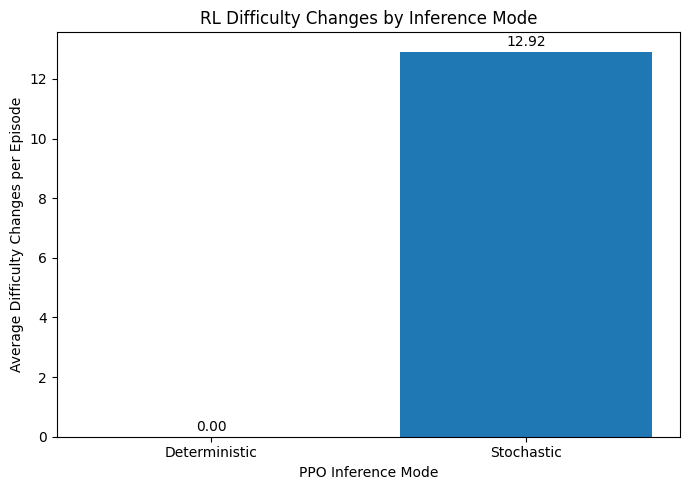

,Inference Mode,Average Difficulty Changes
0,Deterministic,0.00
1,Stochastic,12.92


In [136]:
deterministic_path = (
    RAW_DATA_DIR / "rl_eval_intermediate_rand_6.csv"
)

stochastic_path = (
    RAW_DATA_DIR / "rl_eval_intermediate_stochtic_2.csv"
)

deterministic_eval = pd.read_csv(
    deterministic_path
)

stochastic_eval = pd.read_csv(
    stochastic_path
)

inference_summary = pd.DataFrame(
    {
        "Inference Mode": [
            "Deterministic",
            "Stochastic",
        ],
        "Average Difficulty Changes": [
            deterministic_eval[
                "difficulty_changes"
            ].mean(),
            stochastic_eval[
                "difficulty_changes"
            ].mean(),
        ],
    }
)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    inference_summary["Inference Mode"],
    inference_summary["Average Difficulty Changes"],
)

plt.title("RL Difficulty Changes by Inference Mode")
plt.xlabel("PPO Inference Mode")
plt.ylabel("Average Difficulty Changes per Episode")

for bar, value in zip(
    bars,
    inference_summary["Average Difficulty Changes"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.2,
        f"{value:.2f}",
        ha="center",
    )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rl_deterministic_vs_stochastic_changes.png",
    dpi=300,
)

plt.show()

inference_summary.round(2)

### Interpretation

Deterministic inference produced no difficulty changes, while stochastic inference produced approximately 12.9 changes per episode. This shows that deterministic action selection collapsed to a non-adaptive policy, whereas stochastic sampling preserved active DDA behaviour.

### Training and Stochastic Evaluation Alignment

A useful validation check is whether the deployed stochastic policy behaves similarly to the policy observed during training.

To make the comparison more consistent, intermediate-profile episodes from the final training rollout are compared with the intermediate-profile stochastic evaluation.

In [137]:
training_path = (
    RAW_DATA_DIR / "rl_training_randomised_stochtic.csv"
)

stochastic_eval_path = (
    RAW_DATA_DIR / "rl_eval_intermediate_stochtic_2.csv"
)

training_data = pd.read_csv(
    training_path
)

stochastic_eval_data = pd.read_csv(
    stochastic_eval_path
)

training_intermediate = training_data[
    training_data["profile_name"]
    .astype(str)
    .str.lower()
    .eq("intermediate")
].copy()

alignment_summary = pd.DataFrame(
    {
        "Condition": [
            "Training",
            "Stochastic Evaluation",
        ],
        "Average Difficulty Changes": [
            training_intermediate[
                "difficulty_changes"
            ].mean(),
            stochastic_eval_data[
                "difficulty_changes"
            ].mean(),
        ],
        "Average Difficulty": [
            training_intermediate[
                "average_difficulty"
            ].mean(),
            stochastic_eval_data[
                "average_difficulty"
            ].mean(),
        ],
        "Death Rate (%)": [
            (
                training_intermediate[
                    "player_died"
                ]
                .astype(str)
                .str.lower()
                .isin(["true", "1", "yes"])
                .mean()
                * 100
            ),
            (
                stochastic_eval_data[
                    "player_died"
                ]
                .astype(str)
                .str.lower()
                .isin(["true", "1", "yes"])
                .mean()
                * 100
            ),
        ],
        "Target Range (%)": [
            training_intermediate[
                "target_range_percentage"
            ].mean(),
            stochastic_eval_data[
                "target_range_percentage"
            ].mean(),
        ],
    }
)

alignment_summary.round(2)

,Condition,Average Difficulty Changes,Average Difficulty,Death Rate (%),Target Range (%)
0,Training,12.23,3.45,21.13,37.46
1,Stochastic Evaluation,12.92,3.79,21.67,49.12


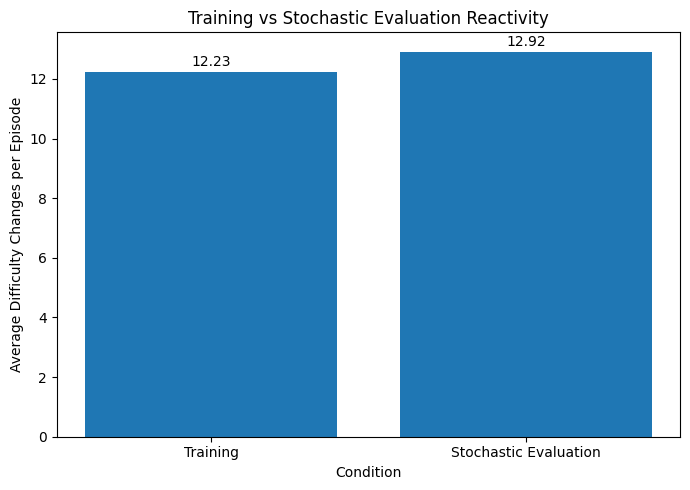

In [138]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    alignment_summary["Condition"],
    alignment_summary[
        "Average Difficulty Changes"
    ],
)

plt.title("Training vs Stochastic Evaluation Reactivity")
plt.xlabel("Condition")
plt.ylabel("Average Difficulty Changes per Episode")

for bar, value in zip(
    bars,
    alignment_summary[
        "Average Difficulty Changes"
    ],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.2,
        f"{value:.2f}",
        ha="center",
    )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rl_training_eval_reactivity.png",
    dpi=300,
)

plt.show()

### Interpretation

The agent made 12.92 difficulty changes per episode during stochastic evaluation compared with 12.23 during training. This close agreement supports the use of stochastic inference as representative of the learned PPO behaviour.

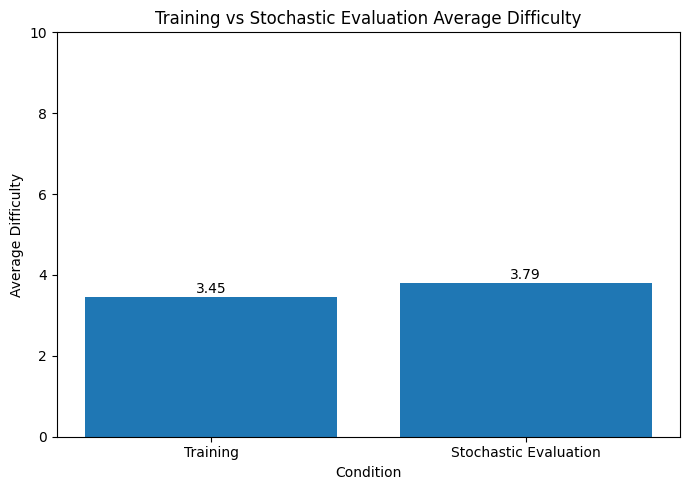

In [139]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    alignment_summary["Condition"],
    alignment_summary[
        "Average Difficulty"
    ],
)

plt.title("Training vs Stochastic Evaluation Average Difficulty")
plt.xlabel("Condition")
plt.ylabel("Average Difficulty")
plt.ylim(0, 10)

for bar, value in zip(
    bars,
    alignment_summary[
        "Average Difficulty"
    ],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.1,
        f"{value:.2f}",
        ha="center",
    )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "rl_training_eval_average_difficulty.png",
    dpi=300,
)

plt.show()

### Interpretation

The stochastic evaluation produced an average difficulty of 3.79 compared with 3.45 during training. The small difference suggests that the deployed stochastic policy behaves similarly to the policy observed during training.

## 10. Statistical Comparison

Descriptive statistics show the practical differences between the difficulty systems, while inferential tests are used to determine whether the observed differences are statistically distinguishable across repeated simulation runs.

Because survival time is bounded at 60 seconds and many runs reach this maximum value, non-parametric tests are used instead of assuming normally distributed outcomes.

Kruskal-Wallis tests are used to compare survival time across the three systems for each simulated player profile.

In [140]:
from scipy.stats import kruskal

survival_test_results = []

for profile in PROFILE_ORDER:
    profile_data = all_results[
        all_results["profile"] == profile
    ]

    static_values = profile_data[
        profile_data["system_name"] == "static"
    ]["survival_time"]

    rule_values = profile_data[
        profile_data["system_name"] == "rule_based"
    ]["survival_time"]

    rl_values = profile_data[
        profile_data["system_name"] == "rl_based"
    ]["survival_time"]

    statistic, p_value = kruskal(
        static_values,
        rule_values,
        rl_values,
    )

    survival_test_results.append(
        {
            "profile": profile,
            "kruskal_H": statistic,
            "p_value": p_value,
            "significant": p_value < 0.05,
        }
    )

survival_test_results = pd.DataFrame(
    survival_test_results
)

survival_test_results.round(4)

,profile,kruskal_H,p_value,significant
0,beginner,0.3713,0.8306,False
1,intermediate,3.8734,0.1442,False
2,skilled,6.1059,0.0472,True
3,inconsistent,6.1581,0.0460,True
4,improving,6.2729,0.0434,True


### Failure Rate Statistical Comparison

A chi-square test is used to examine whether the proportion of deaths and survivals differs between the three difficulty systems for each simulated player profile.

In [141]:
from scipy.stats import chi2_contingency

death_test_results = []

for profile in PROFILE_ORDER:
    profile_data = all_results[
        all_results["profile"] == profile
    ]

    contingency_table = pd.crosstab(
        profile_data["system_name"],
        profile_data["player_died"],
    )

    contingency_table = contingency_table.reindex(
        index=SYSTEM_ORDER,
        columns=[False, True],
        fill_value=0,
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    death_test_results.append(
        {
            "profile": profile,
            "chi_square": chi2,
            "degrees_of_freedom": dof,
            "p_value": p_value,
            "significant": p_value < 0.05,
        }
    )

death_test_results = pd.DataFrame(
    death_test_results
)

death_test_results.round(4)

,profile,chi_square,degrees_of_freedom,p_value,significant
0,beginner,4.1703,2,0.1243,False
1,intermediate,5.3005,2,0.0706,False
2,skilled,6.6667,2,0.0357,True
3,inconsistent,3.4450,2,0.1786,False
4,improving,7.1964,2,0.0274,True


### Target-Range Statistical Comparison

Since target-range percentage was not available for the original static baseline, the following analysis compares only rule-based and RL-based DDA.

The Mann-Whitney U test is used because target-range percentage is bounded and does not require the assumption of normally distributed values.

In [142]:
from scipy.stats import mannwhitneyu

target_range_tests = []

for profile in PROFILE_ORDER:
    profile_data = all_results[
        all_results["profile"] == profile
    ]

    rule_values = (
        profile_data[
            profile_data["system_name"] == "rule_based"
        ]["target_range_percentage"]
        .dropna()
    )

    rl_values = (
        profile_data[
            profile_data["system_name"] == "rl_based"
        ]["target_range_percentage"]
        .dropna()
    )

    statistic, p_value = mannwhitneyu(
        rl_values,
        rule_values,
        alternative="two-sided",
    )

    target_range_tests.append(
        {
            "profile": profile,
            "mann_whitney_U": statistic,
            "p_value": p_value,
            "significant": p_value < 0.05,
        }
    )

target_range_tests = pd.DataFrame(
    target_range_tests
)

target_range_tests.round(4)

,profile,mann_whitney_U,p_value,significant
0,beginner,514.0,0.3478,False
1,intermediate,465.0,0.8302,False
2,skilled,378.0,0.2902,False
3,inconsistent,441.0,0.9000,False
4,improving,561.0,0.1023,False


## 11. Cross-Profile Performance

A successful adaptive system should not only perform well for one simulated player profile.

The following table examines how much the main outcomes vary between profiles. Smaller differences between profiles can indicate more consistent performance across different simulated skill patterns, although this should not be treated as a direct measure of human fairness.

In [143]:
cross_profile_summary = (
    system_summary
    .groupby("system_name", observed=False)
    .agg(
        death_rate_std=("death_rate", "std"),
        survival_time_std=("average_survival_time", "std"),
        average_death_rate=("death_rate", "mean"),
        average_survival_time=("average_survival_time", "mean"),
        average_difficulty_changes=(
            "average_difficulty_changes",
            "mean",
        ),
    )
    .reset_index()
)

cross_profile_summary.round(2)

,system_name,death_rate_std,survival_time_std,average_death_rate,average_survival_time,average_difficulty_changes
0,static,21.29,3.79,45.33,54.64,0.00
1,rule_based,17.09,4.49,44.67,54.32,3.08
2,rl_based,15.02,4.74,31.33,52.55,12.82


## 12. Final Results Summary

The following table provides the main profile-level results used for the final comparison between static difficulty, rule-based DDA, and RL-based DDA.

In [144]:
final_results_table = system_summary[
    [
        "system_name",
        "profile",
        "death_rate",
        "average_survival_time",
        "average_hits_taken",
        "average_difficulty",
        "average_difficulty_changes",
        "average_target_range_percentage",
    ]
].copy()

final_results_table = final_results_table.round(2)

final_results_table.to_csv(
    TABLE_DIR / "final_results_table.csv",
    index=False,
)

final_results_table

,system_name,profile,death_rate,average_survival_time,average_hits_taken,average_difficulty,average_difficulty_changes,average_target_range_percentage
0,static,beginner,73.33,49.45,11.33,5.00,0.00,NaN
1,static,intermediate,36.67,56.26,9.80,5.00,0.00,NaN
2,static,skilled,16.67,59.06,8.53,5.00,0.00,NaN
3,static,inconsistent,43.33,56.20,9.87,5.00,0.00,NaN
4,static,improving,56.67,52.22,10.50,5.00,0.00,NaN
5,rule_based,beginner,70.00,46.68,12.13,4.31,3.20,47.32
6,rule_based,intermediate,36.67,56.27,9.37,4.93,2.90,48.78
7,rule_based,skilled,46.67,55.41,9.40,5.19,3.33,46.96
8,rule_based,inconsistent,23.33,58.44,10.13,4.72,2.97,50.06
9,rule_based,improving,46.67,54.82,10.63,4.52,3.00,46.40


## 13. Final Interpretation

The final comparison evaluates RL-based DDA against both the static and rule-based baselines using several objective gameplay measures.

Death rate and survival time indicate whether the simulated player was being overwhelmed, while health remaining and hits taken provide additional information about gameplay pressure. Average difficulty and difficulty changes show how the adaptive systems responded during gameplay.

The RL system should therefore not be judged simply by whether it produces the lowest death rate. An adaptive system that always reduces difficulty could achieve high survival while failing to maintain meaningful challenge. Instead, the results are interpreted using the combination of player outcomes, target-range occupancy, and difficulty-adjustment behaviour.

Target-range percentage provides the most direct logged measure of the defined balance objective for the adaptive systems. However, this metric was not available for the original static baseline and is therefore used only for the rule-based versus RL-based comparison.

The improving and inconsistent profiles provide particularly useful tests of adaptation because their behaviour is not represented by one fixed skill level. These profiles help determine whether the DDA systems can respond to changing or less predictable simulated gameplay conditions.